# Actividad 1: Modelos predictivos
En esta actividad se busca estudiar la relación entre los videojuegos y diferentes afecciones de salud, sobretodo mental. Para ello usaremos el Dataset de Kaggle "gaming and mental health". Haremos primero un análisis exploratório de datos y usando esos datos como guía entrenaremos diferentes modelos predictivos para ver si se obtienen las mismas conclusiones. Vaos a ver con qué grado se predicen los tipos de ju

##Bloque 1: Análisis predictivo de datos

### Importar datos y librerías




In [1]:
!pip install SciPY
!pip install shap
!pip install kaggle
!pip install PlotLy
!pip install pygwalker
!pip install seaborn
!pip install ydata_profiling
import pandas as pd
import pygwalker as pyg
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.2/956.2 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.4 MB/s eta 0:00:00


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shaistashahid/gaming-and-mental-health")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gaming-and-mental-health' dataset.
Path to dataset files: /kaggle/input/gaming-and-mental-health


In [3]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/My Drive/Colab Notebooks/Mineria/CSV/"
df = pd.read_csv(path + "Gaming and Mental Health.csv")

Mounted at /content/drive


una vez importados los preparamos para el EDA:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [5]:
gm = df.copy()
gm.dropna()
gm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [6]:
gm.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [7]:
report = ProfileReport(gm)
report.to_file("report.html")
report

Output hidden; open in https://colab.research.google.com to view.

cambiamos de tipo de dato los int a float para trbajar con más claridad:

In [8]:
gm['age'] = gm['age'].fillna(0).astype(float)
gm['social_isolation_score'] = gm['social_isolation_score'].fillna(0).astype(float)
gm['years_gaming'] = gm['years_gaming'].fillna(0).astype(float)
gm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   float64
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

Representamos los datos numéricos en histogramas:

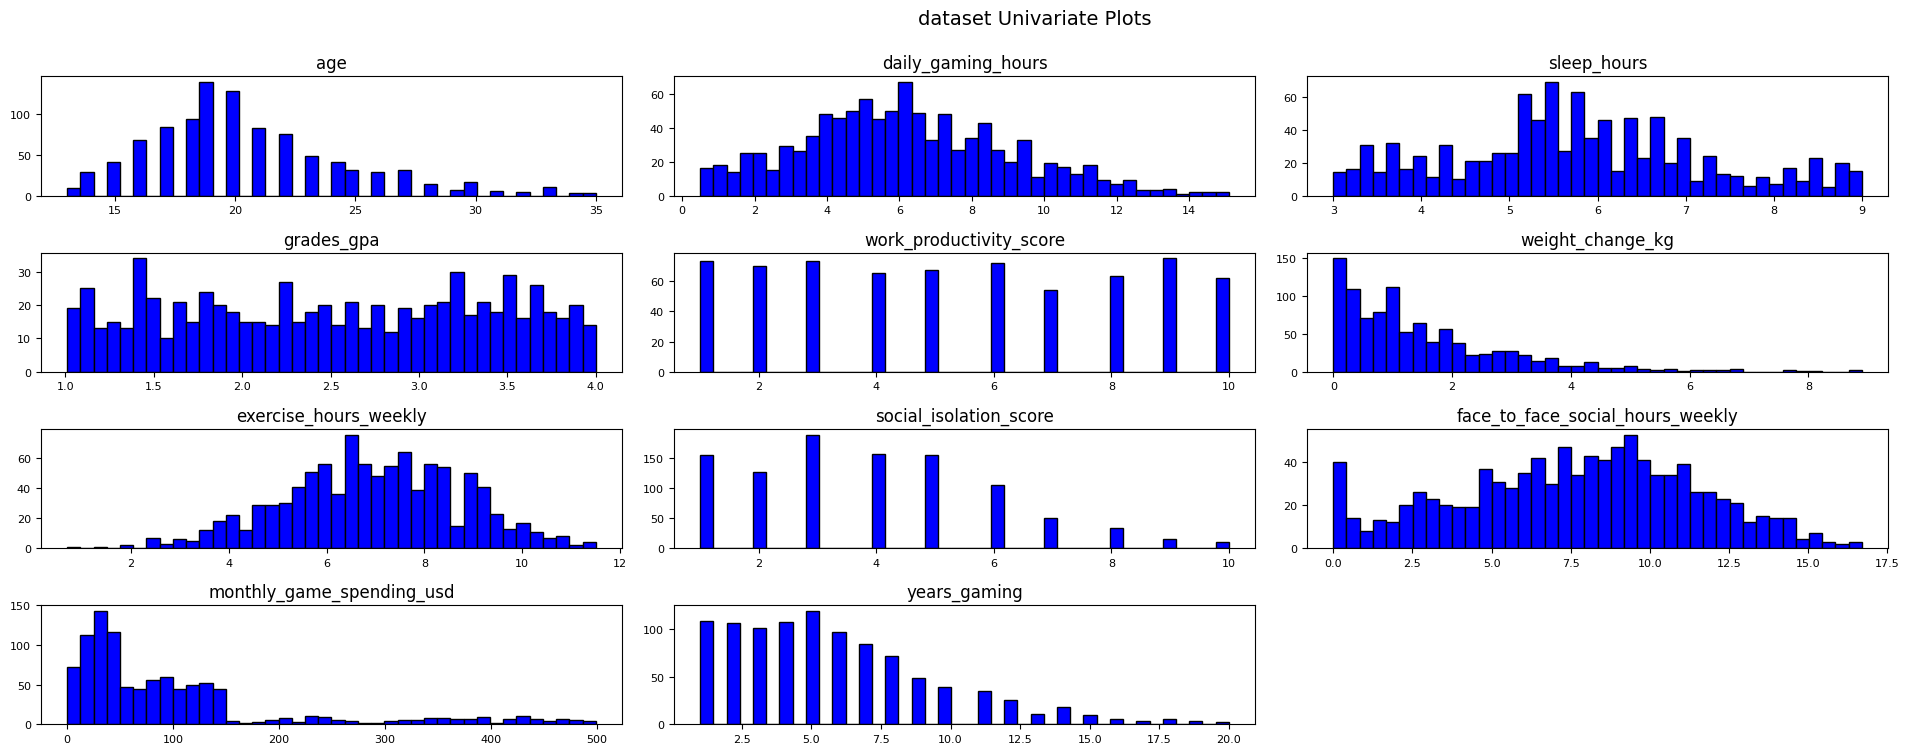

In [9]:
features_list = list(gm.columns)
gm[features_list].hist(bins=40, edgecolor='black', linewidth=1.0,
                          xlabelsize=8, ylabelsize=8, grid=False,
                          figsize=(16,6), color='blue')
plt.tight_layout(rect=(0, 0, 1.2, 1.2))
plt.suptitle('dataset Univariate Plots', x=0.65, y=1.25, fontsize=14);

Los datos categóricos los representamos en diagramas circulares:

La columna 'record_id' tiene demasiados valores únicos (1000) para un diagrama circular legible y ha sido omitida.


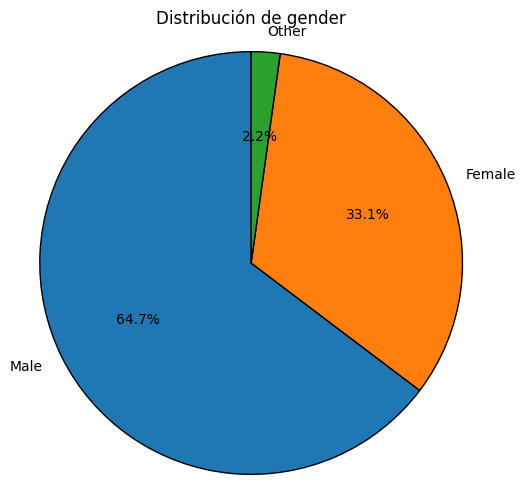

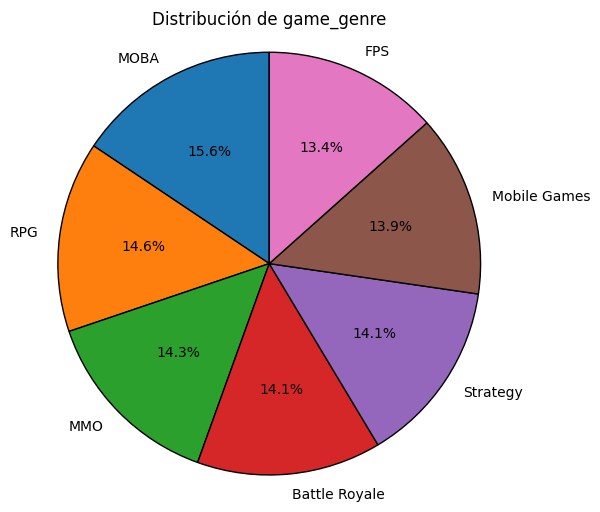

La columna 'primary_game' tiene demasiados valores únicos (24) para un diagrama circular legible y ha sido omitida.


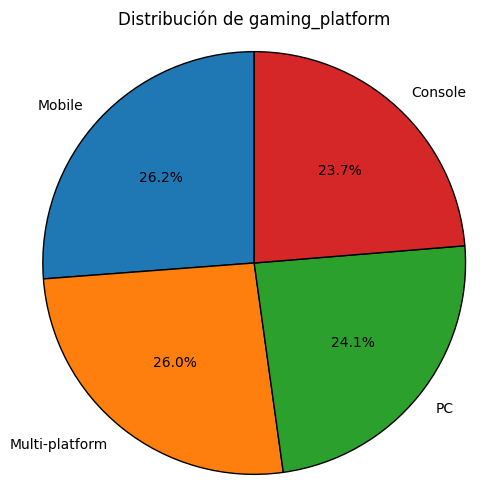

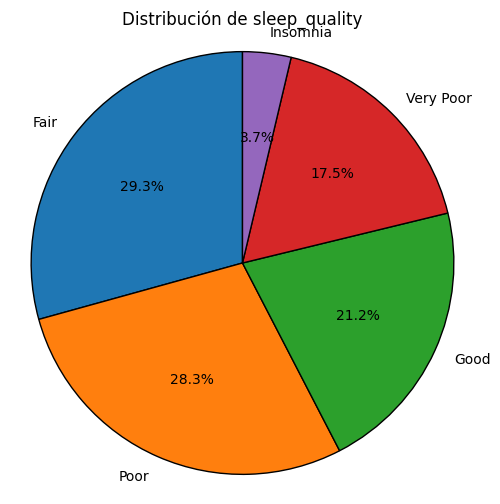

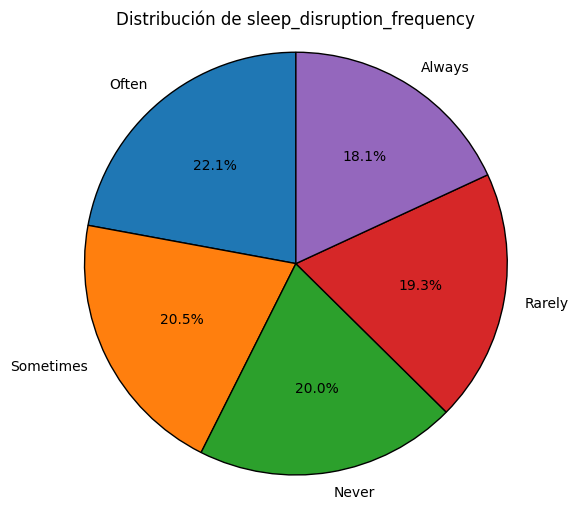

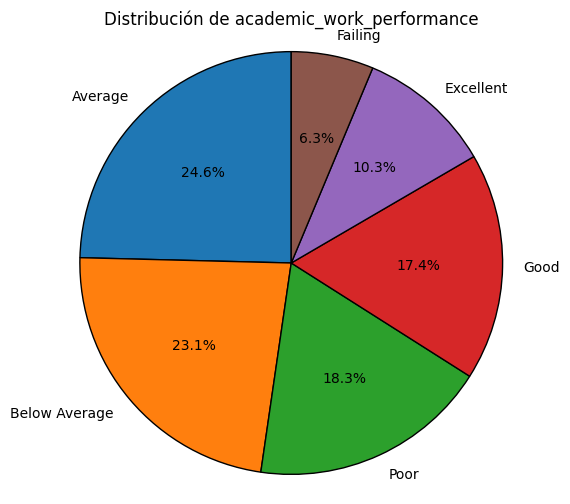

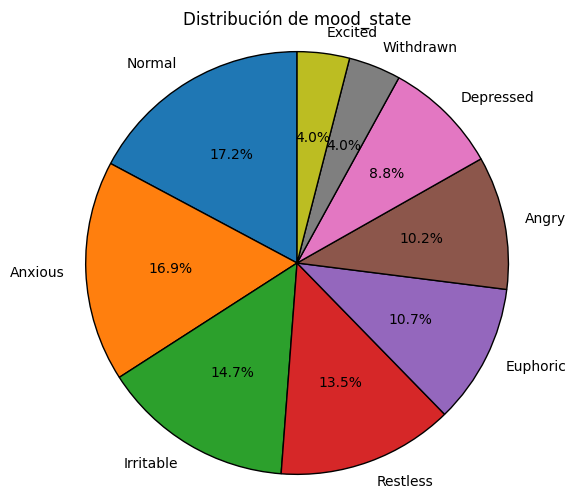

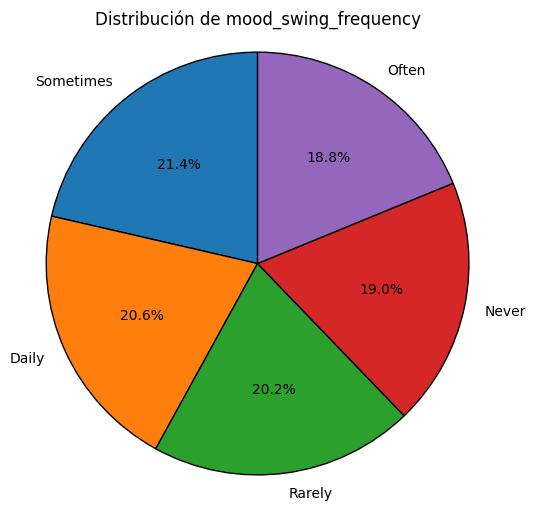

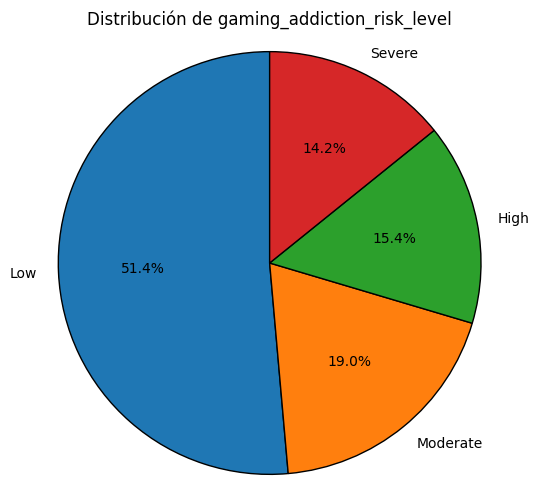

In [10]:
object_columns = gm.select_dtypes(include='object').columns

for col in object_columns:
    # Limitar a columnas con un número razonable de valores únicos para un diagrama circular legible
    if len(gm[col].unique()) <= 15:
        plt.figure(figsize=(6, 6))
        counts = gm[col].value_counts()
        plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
        plt.title(f'Distribución de {col}')
        plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
        plt.show()
    else:
        print(f"La columna '{col}' tiene demasiados valores únicos ({len(gm[col].unique())}) para un diagrama circular legible y ha sido omitida.")

Viendo como los datos de los categóricos están repartidos, está claro que la recogida de datos ha sido sesgada ya que se tienen proporciones perfectas de: plataforma, tipos de juegos, disrupción del sueño y cambios de humor.

### Mapa de calor de correlación para todas las variables (numéricas y categóricas codificadas)

Para incluir variables categóricas en un mapa de calor de correlación, primero las codificaremos numéricamente. También manejaremos los valores faltantes y eliminaremos las columnas que no son adecuadas para este tipo de análisis (como identificadores o variables categóricas con demasiados valores únicos).

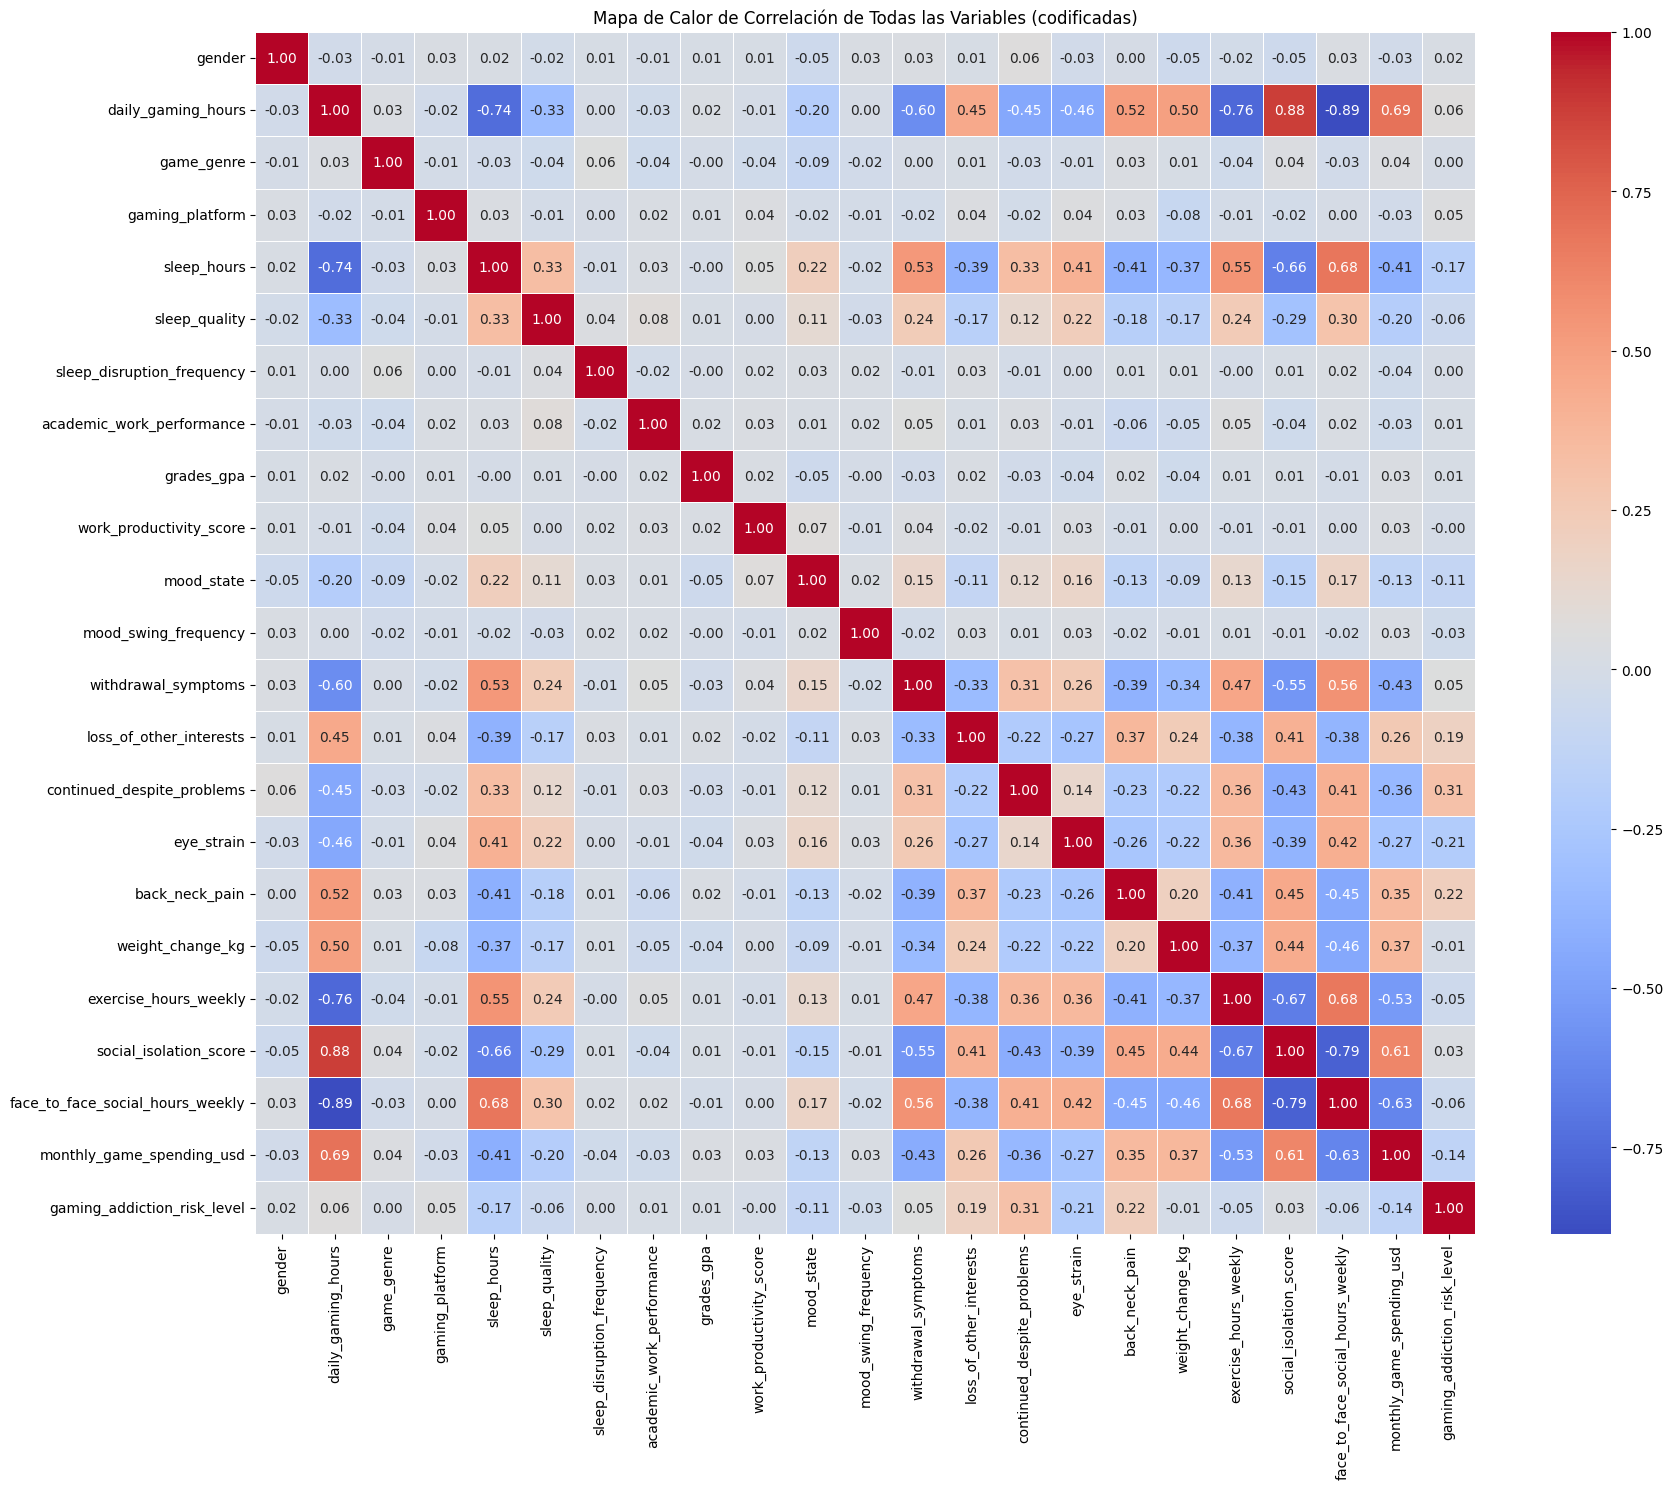

In [11]:
# Crear una copia del DataFrame para no modificar el original
gm_encoded = gm.copy()

# Eliminar columnas que no son relevantes para la correlación o tienen alta cardinalidad
gm_encoded = gm_encoded.drop(columns=['record_id', 'primary_game','age','years_gaming'])

# Imputar valores faltantes en columnas numéricas con la media
gm_encoded['grades_gpa'] = gm_encoded['grades_gpa'].fillna(gm_encoded['grades_gpa'].mean())
gm_encoded['work_productivity_score'] = gm_encoded['work_productivity_score'].fillna(gm_encoded['work_productivity_score'].mean())

# Codificar variables categóricas a numéricas usando pd.factorize
for col in gm_encoded.select_dtypes(include=['object', 'bool']).columns:
    gm_encoded[col], _ = pd.factorize(gm_encoded[col])

# Calcular la matriz de correlación
correlation_matrix = gm_encoded.corr()

# Configurar el tamaño de la figura para el mapa de calor
plt.figure(figsize=(18, 15))

# Crear el mapa de calor
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de Correlación de Todas las Variables (codificadas)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Filtrar y visualizar variables con correlaciones altas

Para destacar las relaciones más significativas, filtraremos la matriz de correlación para incluir solo aquellas variables que tienen una correlación absoluta con otra variable superior a un umbral determinado (por ejemplo, 0.4).

como las variables "age" y "year gaming" solo se relacionan ente ellas (cuantos más años tienen más años llevan jugando), las vamos a purgar del heatmap

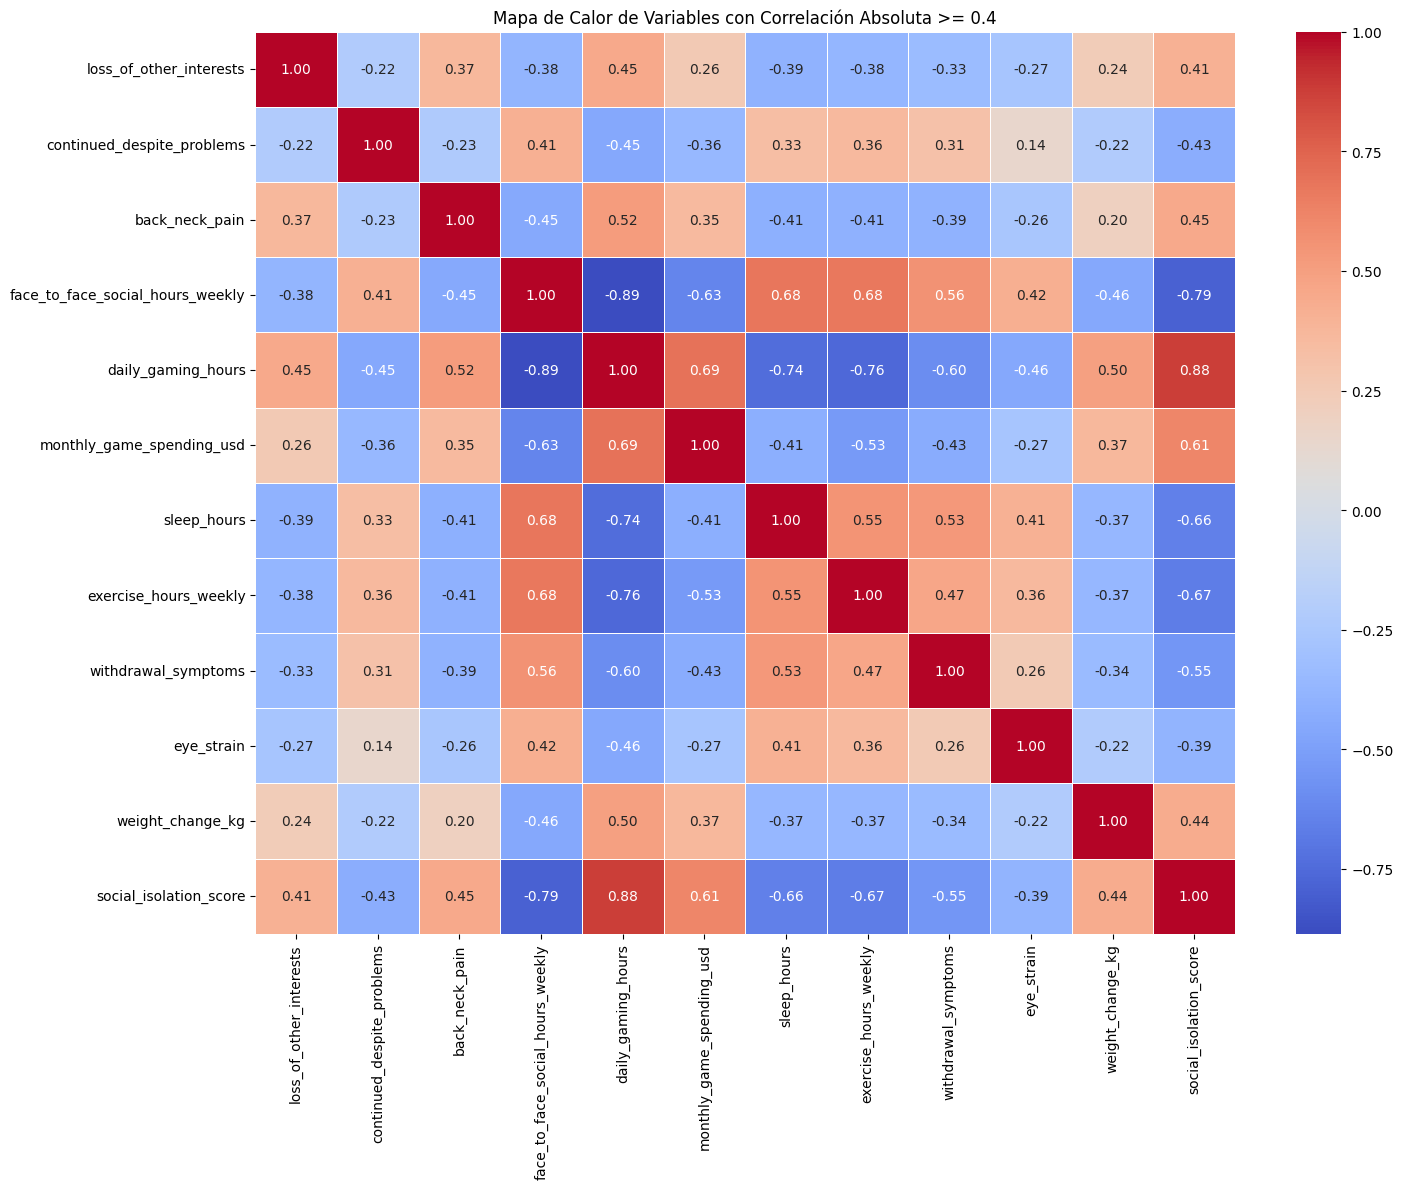

In [12]:
# Definir un umbral para las correlaciones altas
correlation_threshold = 0.4

# Obtener la matriz de correlación absoluta
abs_correlation_matrix = correlation_matrix.abs()

# Identificar las variables con al menos una correlación alta (excluyendo la correlación consigo misma)
highly_correlated_vars = set()
for col in abs_correlation_matrix.columns:
    for row in abs_correlation_matrix.index:
        if col != row and abs_correlation_matrix.loc[row, col] >= correlation_threshold:
            highly_correlated_vars.add(col)
            highly_correlated_vars.add(row)

# Crear una sub-matriz de correlación solo con las variables identificadas
if highly_correlated_vars:
    filtered_correlation_matrix = correlation_matrix.loc[list(highly_correlated_vars), list(highly_correlated_vars)]

    # Configurar el tamaño de la figura para el nuevo mapa de calor
    plt.figure(figsize=(15, 12))

    # Crear el mapa de calor filtrado
    sns.heatmap(filtered_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title(f'Mapa de Calor de Variables con Correlación Absoluta >= {correlation_threshold}')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print(f"No se encontraron variables con correlaciones absolutas >= {correlation_threshold}")

Ahora que ya tenemos las variables más correlacionadas entre ellas, vamos a estudiarlas con más profundidad:

/tmp/ipykernel_32950/2503290392.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='daily_gaming_hours', data=gm, palette='plasma')


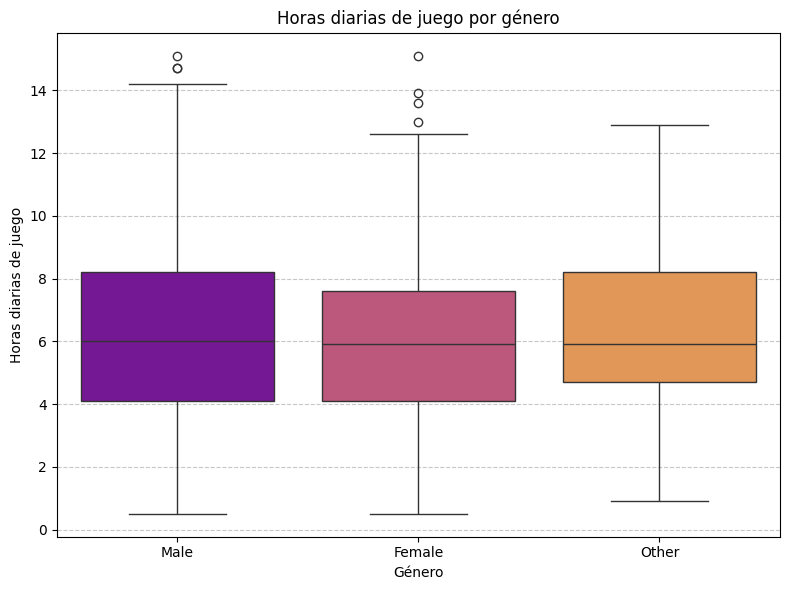

/tmp/ipykernel_32950/2503290392.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gender', y='daily_gaming_hours', data=gm, palette='plasma')


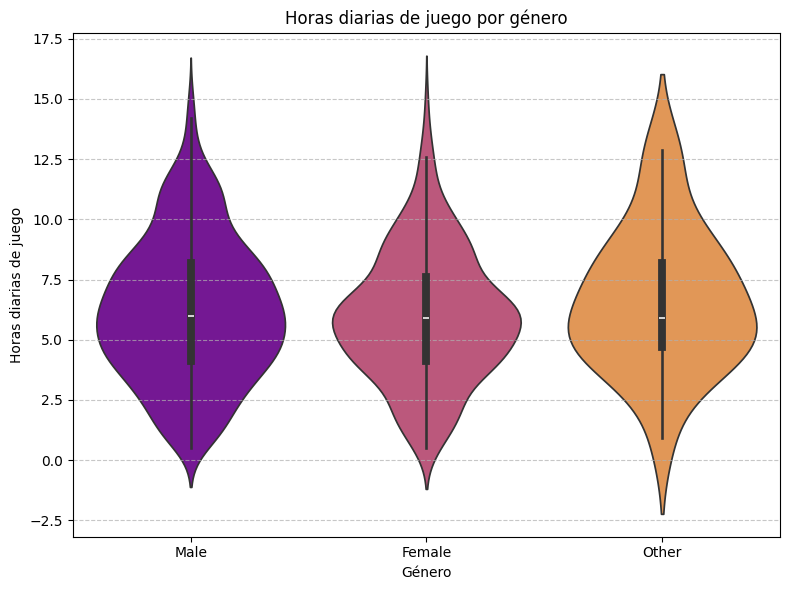

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='daily_gaming_hours', data=gm, palette='plasma')
plt.title('Horas diarias de juego por género')
plt.xlabel('Género')
plt.ylabel('Horas diarias de juego')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
###########################
plt.figure(figsize=(8, 6))
sns.violinplot(x='gender', y='daily_gaming_hours', data=gm, palette='plasma')
plt.title('Horas diarias de juego por género')
plt.xlabel('Género')
plt.ylabel('Horas diarias de juego')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Las horas de juego no parecen tener relación con el género de las personas, como se puede ver los boxplots son similares.

Como al final nos interesa ver el riego de adicción en el dataset, vamos a comparar ese dato con otros para perfilar nuestro dataset ver con qué acierto predice el machine learning.

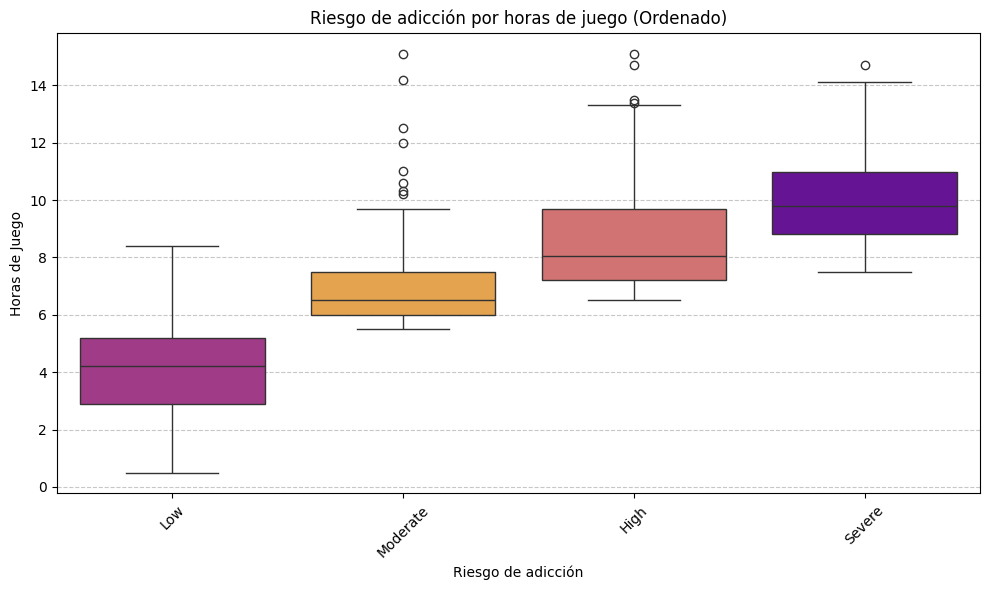

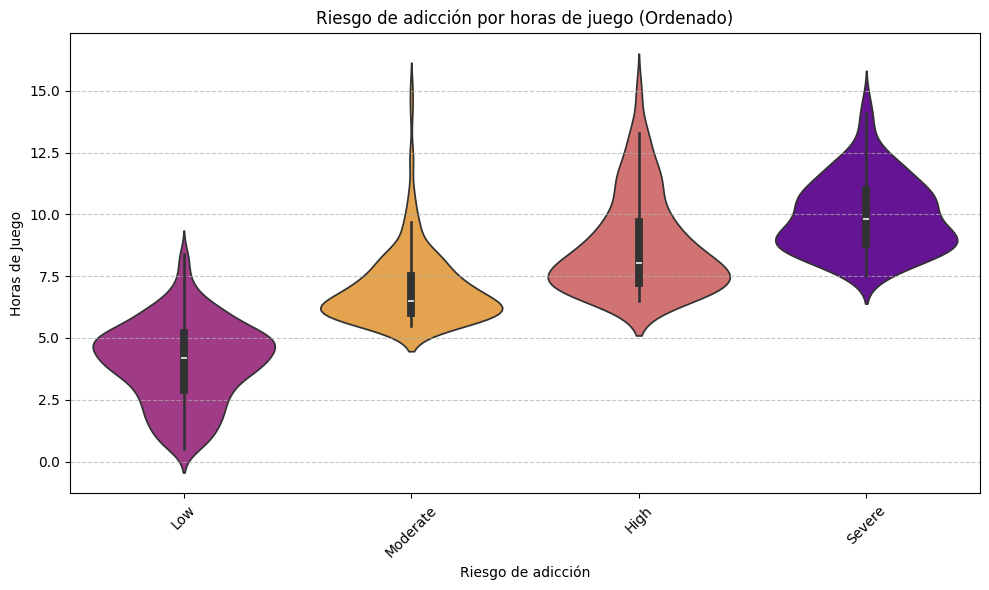

In [14]:
plt.figure(figsize=(10, 6))
# Definir el orden deseado para las categorías
addiction_risk_order = ['Low', 'Moderate', 'High', 'Severe']
sns.boxplot(x='gaming_addiction_risk_level', y='daily_gaming_hours', data=gm, palette='plasma', order=addiction_risk_order, hue='gaming_addiction_risk_level', legend=False)
plt.title('Riesgo de adicción por horas de juego (Ordenado)')
plt.xlabel('Riesgo de adicción')
plt.ylabel('Horas de Juego')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
########################
plt.figure(figsize=(10, 6))
addiction_risk_order = ['Low', 'Moderate', 'High', 'Severe']
sns.violinplot(x='gaming_addiction_risk_level', y='daily_gaming_hours', data=gm, palette='plasma', order=addiction_risk_order, hue='gaming_addiction_risk_level', legend=False)
plt.title('Riesgo de adicción por horas de juego (Ordenado)')
plt.xlabel('Riesgo de adicción')
plt.ylabel('Horas de Juego')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

A  mayor riesgo de adicción más horas de juego, esto concuerda con lo esperado. De forma análoga, las horas de sueño disminuyen por nivel de riesgo ( más horas jugando = menos horas durmiendo).

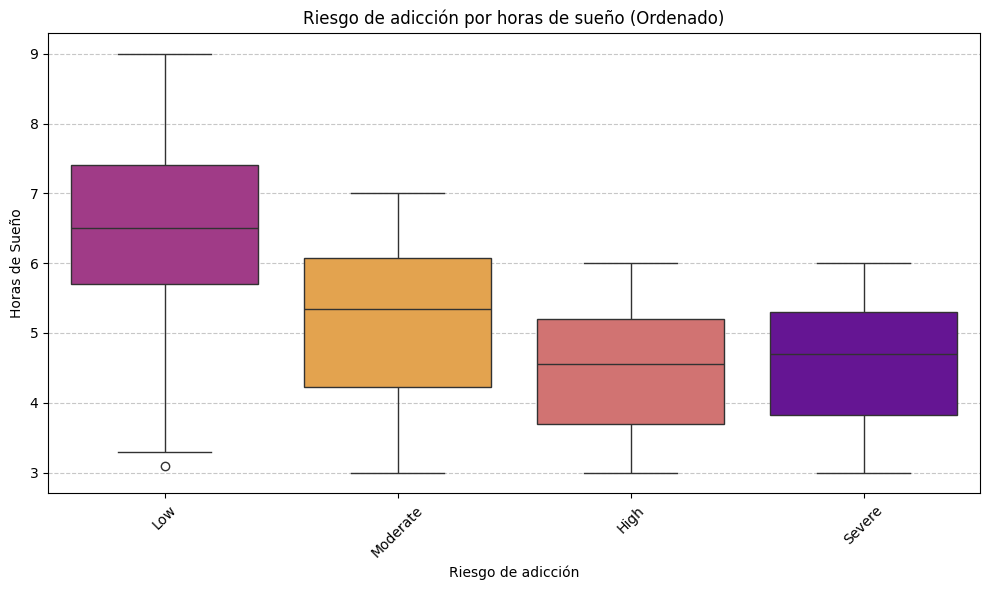

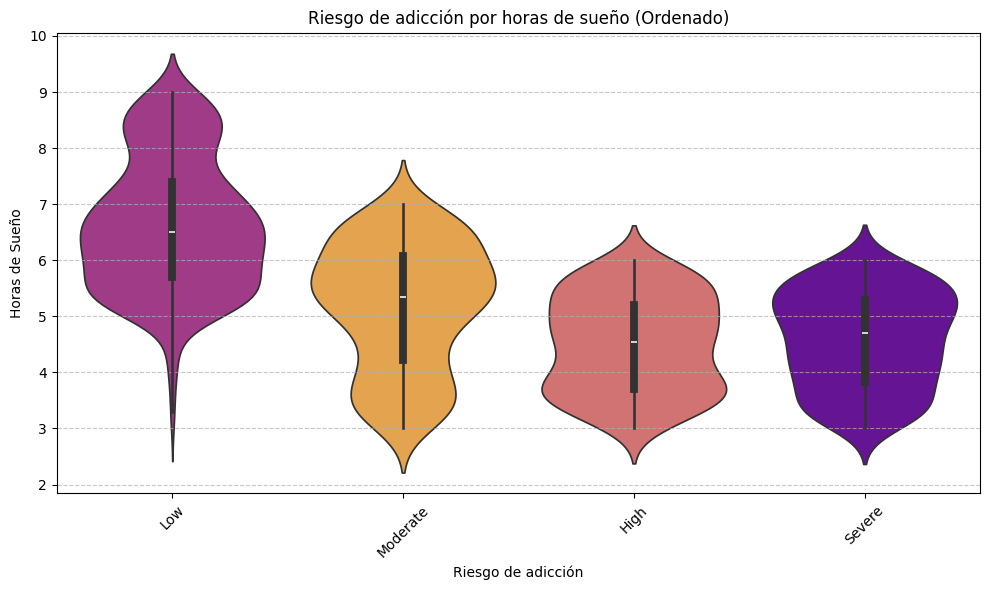

In [15]:
plt.figure(figsize=(10, 6))
addiction_risk_order = ['Low', 'Moderate', 'High', 'Severe']
sns.boxplot(x='gaming_addiction_risk_level', y='sleep_hours', data=gm, palette='plasma', order=addiction_risk_order, hue='gaming_addiction_risk_level', legend=False)
plt.title('Riesgo de adicción por horas de sueño (Ordenado)')
plt.xlabel('Riesgo de adicción')
plt.ylabel('Horas de Sueño')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
####################
plt.figure(figsize=(10, 6))
# Definir el orden deseado para las categorías
addiction_risk_order = ['Low', 'Moderate', 'High', 'Severe']
sns.violinplot(x='gaming_addiction_risk_level', y='sleep_hours', data=gm, palette='plasma', order=addiction_risk_order, hue='gaming_addiction_risk_level', legend=False)
plt.title('Riesgo de adicción por horas de sueño (Ordenado)')
plt.xlabel('Riesgo de adicción')
plt.ylabel('Horas de Sueño')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

También buscamos como estos niveles de adicción castigan al cuerpo, viendo como aumenta de peso la gente ( cabe recalcar que el dataset sólo incluía aumento del peso, en nigún caso disminución, por lo que no sabemos hasta que punto la variación es consecuencia del nivel de adicción).

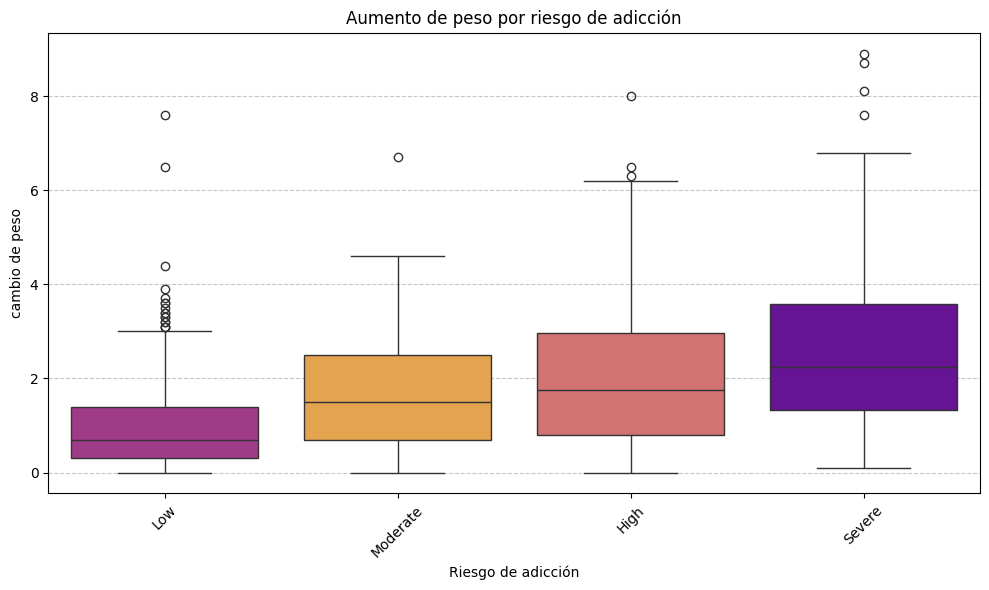

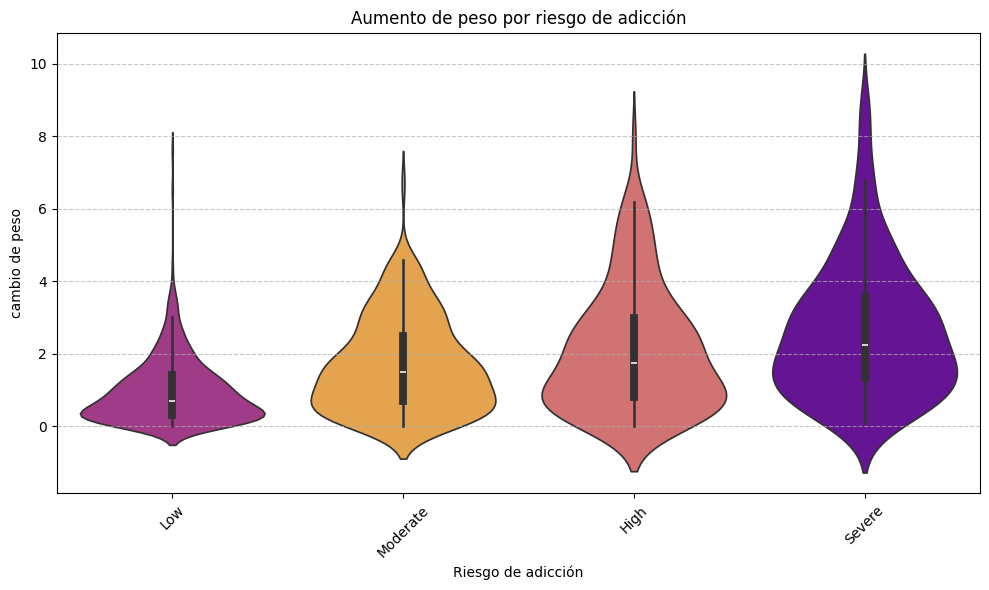

In [16]:
plt.figure(figsize=(10, 6))
# Definir el orden deseado para las categorías
addiction_risk_order = ['Low', 'Moderate', 'High', 'Severe']
sns.boxplot(x='gaming_addiction_risk_level', y='weight_change_kg', data=gm, palette='plasma', order=addiction_risk_order, hue='gaming_addiction_risk_level', legend=False)
plt.title('Aumento de peso por riesgo de adicción')
plt.xlabel('Riesgo de adicción')
plt.ylabel('cambio de peso')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
##################
plt.figure(figsize=(10, 6))
# Definir el orden deseado para las categorías
addiction_risk_order = ['Low', 'Moderate', 'High', 'Severe']
sns.violinplot(x='gaming_addiction_risk_level', y='weight_change_kg', data=gm, palette='plasma', order=addiction_risk_order, hue='gaming_addiction_risk_level', legend=False)
plt.title('Aumento de peso por riesgo de adicción')
plt.xlabel('Riesgo de adicción')
plt.ylabel('cambio de peso')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Por último, comparamos la calidad del suño con el nº de horas dormidas, para sorpresa de nadie a mayor nº de horas dormidas, mayor calidad del sueño:

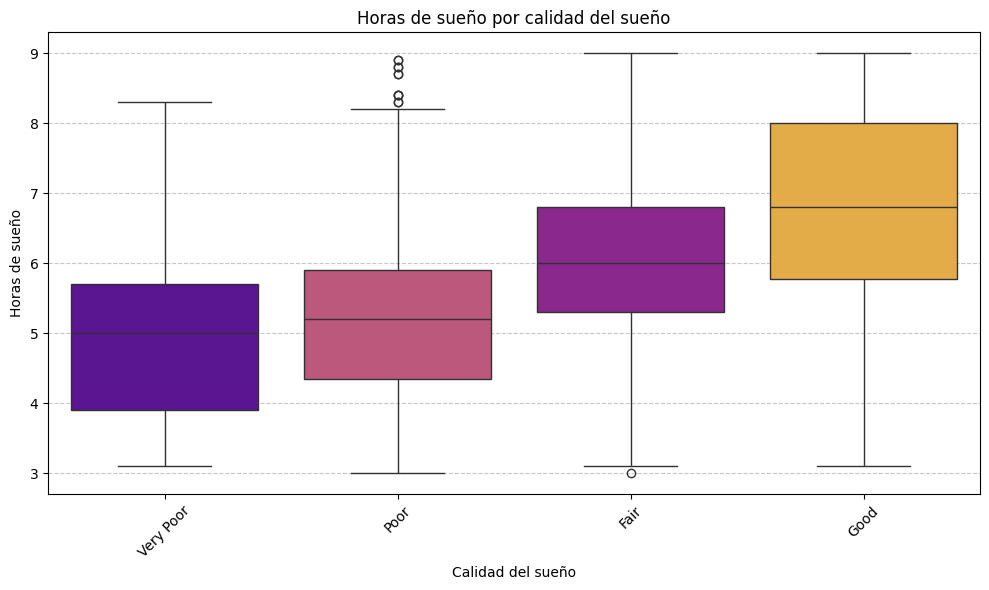

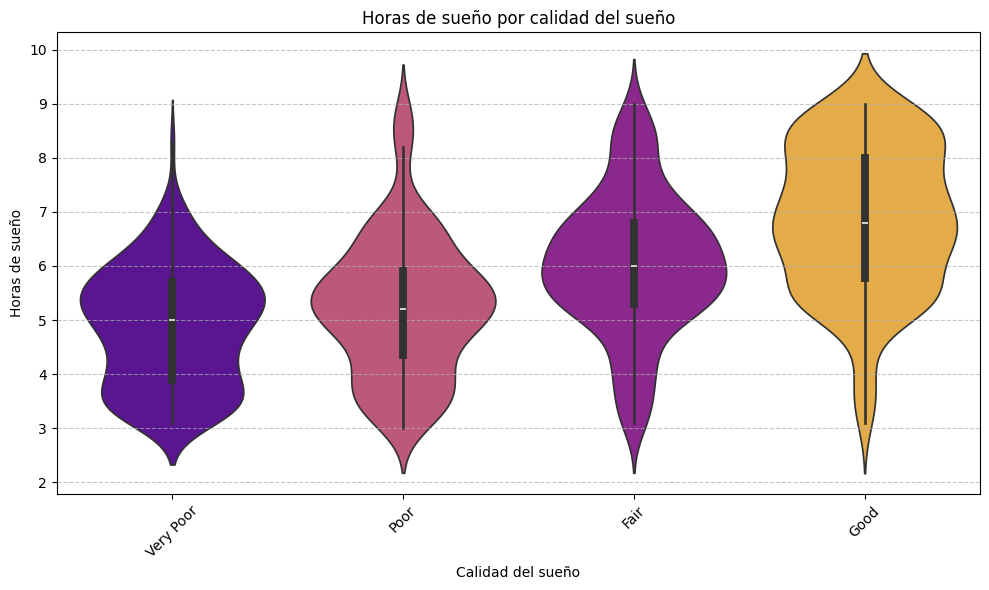

In [17]:
plt.figure(figsize=(10, 6))
# Definir el orden deseado para las categorías de calidad del sueño
# Se asume que estas son las categorías presentes en la columna 'sleep_quality'
orden_calidad_sueño = ['Very Poor', 'Poor', 'Fair', 'Good']
sns.boxplot(x='sleep_quality', y='sleep_hours', data=gm, palette='plasma', order=orden_calidad_sueño, hue='sleep_quality', legend=False)
plt.title('Horas de sueño por calidad del sueño')
plt.xlabel('Calidad del sueño')
plt.ylabel('Horas de sueño')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
####################
plt.figure(figsize=(10, 6))
orden_calidad_sueño = ['Very Poor', 'Poor', 'Fair', 'Good']
sns.violinplot(x='sleep_quality', y='sleep_hours', data=gm, palette='plasma', order=orden_calidad_sueño, hue='sleep_quality', legend=False)
plt.title('Horas de sueño por calidad del sueño')
plt.xlabel('Calidad del sueño')
plt.ylabel('Horas de sueño')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Ahora vamos a comparar la el riesgo de adicción con el tipo de juego, y la plataforma en la que juegan:

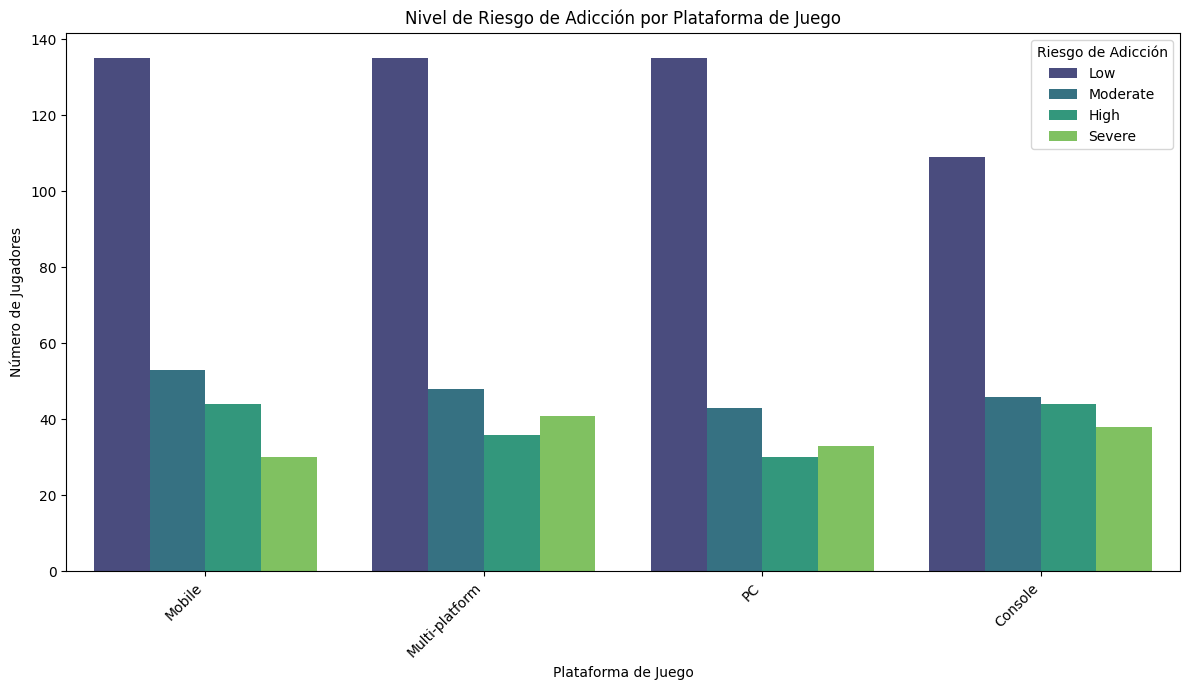

In [18]:
plt.figure(figsize=(12, 7))
addiction_risk_order = ['Low', 'Moderate', 'High', 'Severe']
sns.countplot(data=gm, x='gaming_platform', hue='gaming_addiction_risk_level', palette='viridis', order=gm['gaming_platform'].value_counts().index, hue_order=addiction_risk_order)
plt.title('Nivel de Riesgo de Adicción por Plataforma de Juego')
plt.xlabel('Plataforma de Juego')
plt.ylabel('Número de Jugadores')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Riesgo de Adicción')
plt.tight_layout()
plt.show()

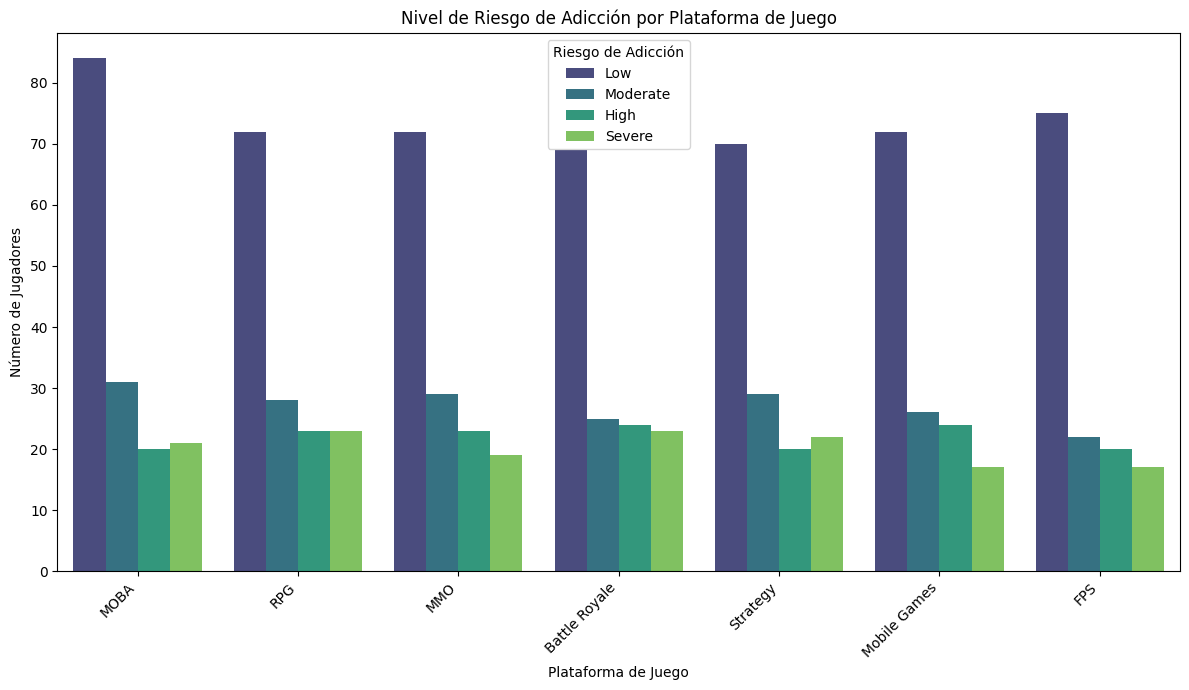

In [19]:
plt.figure(figsize=(12, 7))
addiction_risk_order = ['Low', 'Moderate', 'High', 'Severe']
sns.countplot(data=gm, x='game_genre', hue='gaming_addiction_risk_level', palette='viridis', order=gm['game_genre'].value_counts().index, hue_order=addiction_risk_order)
plt.title('Nivel de Riesgo de Adicción por Plataforma de Juego')
plt.xlabel('Plataforma de Juego')
plt.ylabel('Número de Jugadores')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Riesgo de Adicción')
plt.tight_layout()
plt.show()

##Bloque 2: ML
EL objetivo del bloque 2 va a ser ver con qué precisión pueden los modelos de ML predecir en qué grupo de riesgo de adicción está cada persona:

### Preparación de los datos para Machine Learning

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Tomar los datos nuevamente
path = "/content/drive/My Drive/Colab Notebooks/Mineria/CSV/"
df = pd.read_csv(path + "Gaming and Mental Health.csv")
gm = df.copy()

# Volvemos a aplicar los cambios en los datos que hicimos en su momento para el EDA
gm['age'] = gm['age'].fillna(0).astype(float)
gm['social_isolation_score'] = gm['social_isolation_score'].fillna(0).astype(float)
gm['years_gaming'] = gm['years_gaming'].fillna(0).astype(float)

# Imputar valores faltantes para 'grades_gpa' y 'work_productivity_score' con la media
gm_ml = gm.copy()
gm_ml['grades_gpa'].fillna(gm_ml['grades_gpa'].mean(), inplace=True);
gm_ml['work_productivity_score'].fillna(gm_ml['work_productivity_score'].mean(), inplace=True);

# Eliminar 'record_id' y 'primary_game' ya que son identificadores o tienen demasiados valores únicos
gm_ml = gm_ml.drop(columns=['record_id', 'primary_game']);

# Codificar la variable objetivo 'gaming_addiction_risk_level'
le = LabelEncoder()
gm_ml['gaming_addiction_risk_level_encoded'] = le.fit_transform(gm_ml['gaming_addiction_risk_level'])

# Guardar el mapeo de la variable objetivo para futuras referencias
addiction_risk_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapeo de 'gaming_addiction_risk_level':", addiction_risk_mapping)

# Codificar otras variables categóricas (objeto y booleanas) utilizando Label Encoding
# Para un mejor rendimiento en algunos modelos, se podría considerar One-Hot Encoding
for col in gm_ml.select_dtypes(include=['object', 'bool']).columns:
    if col != 'gaming_addiction_risk_level': # Ya hemos codificado esta
        gm_ml[col] = le.fit_transform(gm_ml[col])

# Definir características (X) y variable objetivo (y)
X = gm_ml.drop(columns=['gaming_addiction_risk_level', 'gaming_addiction_risk_level_encoded'])
y = gm_ml['gaming_addiction_risk_level_encoded']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

display(X_train.head())

Mapeo de 'gaming_addiction_risk_level': {'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2), 'Severe': np.int64(3)}
Dimensiones de X_train: (700, 24)
Dimensiones de X_test: (300, 24)
Dimensiones de y_train: (700,)
Dimensiones de y_test: (300,)


/tmp/ipykernel_32950/970569296.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gm_ml['grades_gpa'].fillna(gm_ml['grades_gpa'].mean(), inplace=True);
/tmp/ipykernel_32950/970569296.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(valu

,age,gender,daily_gaming_hours,game_genre,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,...,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
19,20.0,1,9.4,0,0,5.5,3,4,1,2.140000,...,1,0,0,1,1.7,4.8,7.0,2.2,120.16,1.0
132,13.0,1,4.0,0,0,5.1,3,0,0,1.420000,...,0,0,0,0,0.4,6.4,2.0,12.1,27.46,1.0
525,16.0,1,1.7,1,2,8.2,3,4,2,3.030000,...,0,0,0,0,0.8,7.6,1.0,9.7,12.32,4.0
287,17.0,1,3.6,1,3,6.1,4,3,4,1.080000,...,0,0,0,0,0.9,6.4,3.0,10.2,15.92,5.0
257,27.0,1,14.2,6,2,3.4,4,3,3,2.518037,...,0,0,1,1,4.4,2.9,9.0,0.0,73.80,10.0


### Entrenamiento y Evaluación del Modelo de Regresión Logística

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Acierto del modelo de Regresión Logística: 0.8633

Informe de Clasificación del modelo de Regresión Logística:
               precision    recall  f1-score   support

           0       0.59      0.48      0.53        46
           1       0.99      0.99      0.99       154
           2       0.73      0.82      0.78        57
           3       0.84      0.86      0.85        43

    accuracy                           0.86       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.86      0.86      0.86       300



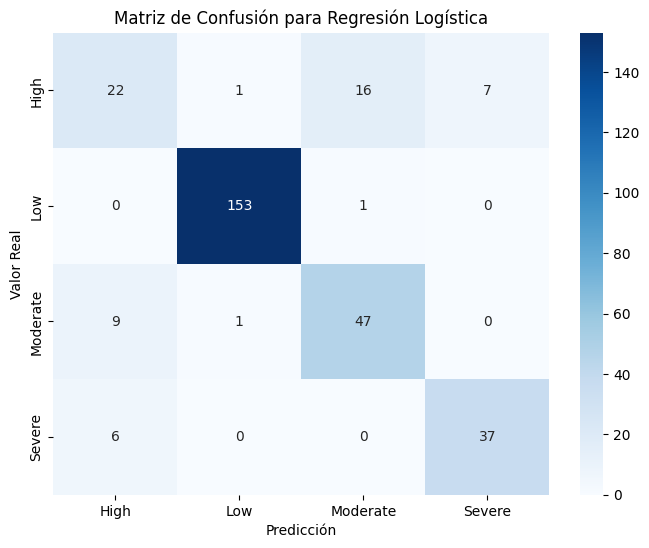

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Inicializar el modelo de Regresión Logística
# Usamos solver='liblinear' para datasets pequeños y cuando hay multiclass, y class_weight='balanced' para manejar posibles desequilibrios en las clases de riesgo.
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, multi_class='auto', class_weight='balanced')

# Entrenar el modelo con los datos de entrenamiento
log_reg_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
report_log_reg = classification_report(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print(f"Acierto del modelo de Regresión Logística: {accuracy_log_reg:.4f}")
print("\nInforme de Clasificación del modelo de Regresión Logística:\n", report_log_reg)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(addiction_risk_mapping.keys()),
            yticklabels=list(addiction_risk_mapping.keys()))
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Regresión Logística')
plt.show()

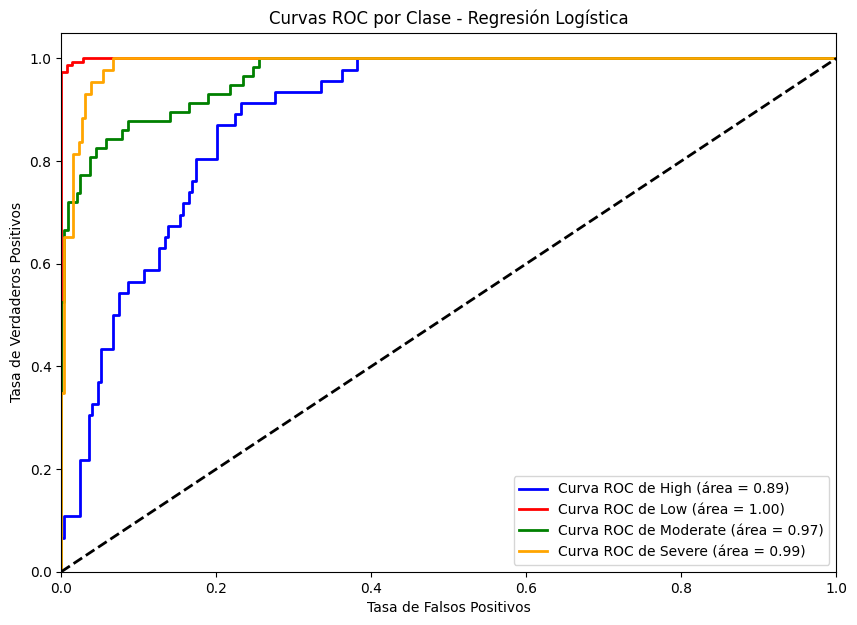

In [22]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarizar la salida para multiclasificación
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

# Obtener las probabilidades de predicción
y_score = log_reg_model.predict_proba(X_test)

# Calcular la curva ROC y el área AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar
plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange']
class_names = list(addiction_risk_mapping.keys())

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Curva ROC de {class_names[i]} (área = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por Clase - Regresión Logística')
plt.legend(loc="lower right")
plt.show()

AUC (Área Bajo la Curva): Cuanto más cerca esté el valor de 1.0, mejor es el modelo separando esa clase de las demás.
Clase 'Low' (AUC = 1.00): Como vimos en el accuracy, el modelo es perfecto distinguiendo el riesgo bajo.
Clase 'Severe' (AUC = 0.99) y 'Moderate' (AUC = 0.97): El modelo también tiene una capacidad excelente para detectar estos niveles.
Clase 'High' (AUC = 0.89): Es el valor más bajo, lo que confirma que el modelo de Regresión Logística tiene más dificultades para diferenciar el riesgo 'High' de los otros niveles (especialmente de 'Moderate' o 'Severe' como vimos en la matriz de confusión).

## Clustering de Tipos de Jugadores

Vamos a usar K-Means para identificar segmentos o 'tipos de jugadores' basados en sus características de juego y salud mental. Esto nos ayudará a entender patrones intrínsecos en los datos sin una variable objetivo predefinida.

### Preparación de Datos para Clustering

Para K-Means, es crucial que las características numéricas estén escaladas para que ninguna característica domine la distancia euclidiana debido a su rango de valores.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una copia del DataFrame gm_ml para clustering
df_clustering = gm_ml.copy()

# Eliminar la variable objetivo y otras variables no relevantes o que ya fueron codificadas como objetivo
df_clustering = df_clustering.drop(columns=['gaming_addiction_risk_level', 'gaming_addiction_risk_level_encoded'])

# Identificar columnas numéricas para escalado y categóricas ya codificadas
numerical_cols = df_clustering.select_dtypes(include=['float64', 'int64']).columns

# Escalar las características numéricas
scaler = StandardScaler()
df_clustering[numerical_cols] = scaler.fit_transform(df_clustering[numerical_cols])

# Mostrar las primeras filas del DataFrame escalado
display(df_clustering.head())


,age,gender,daily_gaming_hours,game_genre,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,academic_work_performance,grades_gpa,...,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
0,-0.844667,0.608911,1.726802,0.493742,1.361357,-1.414863,1.415373,1.408180,-0.655164,-1.675184e+00,...,-0.692308,2.488824,1.006018,-0.730577,3.693060,-1.799156,1.496391,-1.694498,2.446462,-0.740929
1,0.127612,0.608911,-1.099674,-0.010076,1.361357,1.014861,-1.199635,0.689354,0.933755,1.627527e+00,...,-0.692308,-0.401796,-0.994018,-0.730577,-0.777788,0.861415,-0.895538,0.812117,-0.514626,-1.270920
2,0.613751,0.608911,0.505486,-1.017713,0.450750,-0.928918,-1.199635,-0.029472,1.463394,-5.866794e-16,...,1.444444,2.488824,-0.994018,1.368782,0.200210,0.085415,0.539619,-1.187842,-0.038740,0.054059
3,-0.115458,-1.361675,0.365906,0.997560,0.450750,-0.442974,-1.199635,-0.029472,1.463394,-1.186383e+00,...,1.444444,-0.401796,1.006018,1.368782,-0.917502,-0.967727,0.061233,0.385459,-0.471052,0.319055
4,-0.601598,0.608911,0.226327,-1.521531,1.361357,-1.623126,0.761621,-0.748298,-1.184804,-1.030937e-01,...,-0.692308,-0.401796,-0.994018,-0.730577,-0.707931,-0.468870,0.061233,-0.841183,-0.638231,-1.270920


### Método del Codo para Determinar el Número Óptimo de Clusters (K)

El método del codo nos ayuda a encontrar el número de clusters (K) más apropiado para nuestros datos, buscando el punto donde la reducción de la suma de los cuadrados dentro de los clusters (WCSS) comienza a disminuir más lentamente, formando una especie de 'codo' en el gráfico.

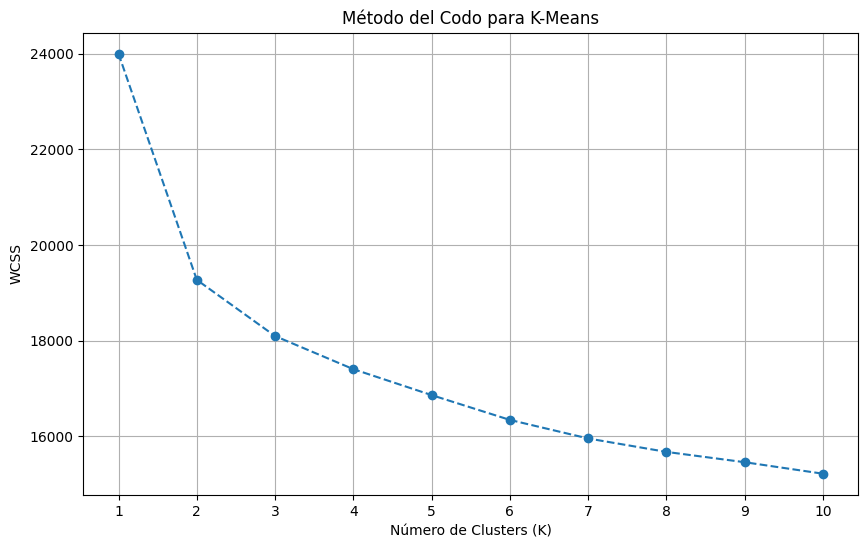

In [24]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df_clustering)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


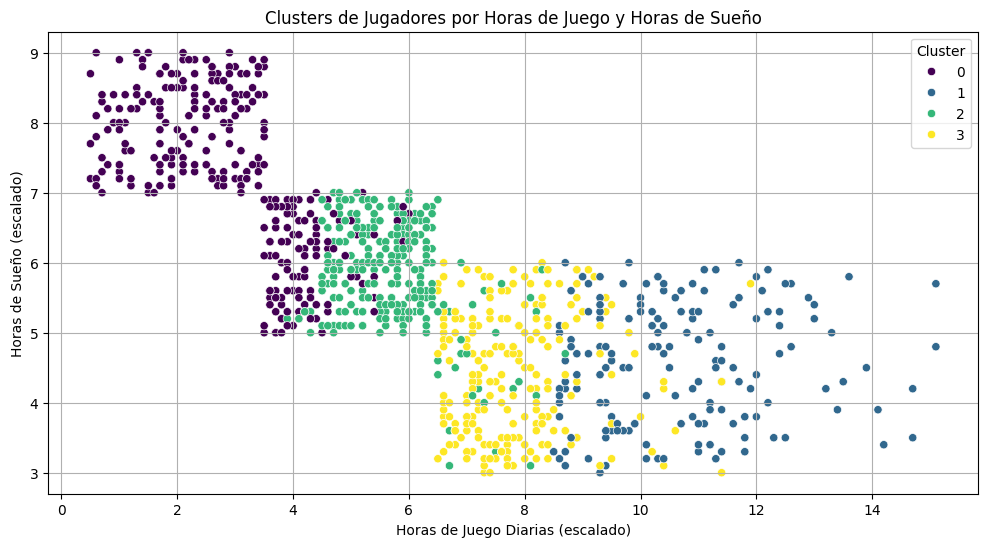

/tmp/ipykernel_32950/3651141248.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gm_ml, x='Cluster', y='daily_gaming_hours', palette='viridis')


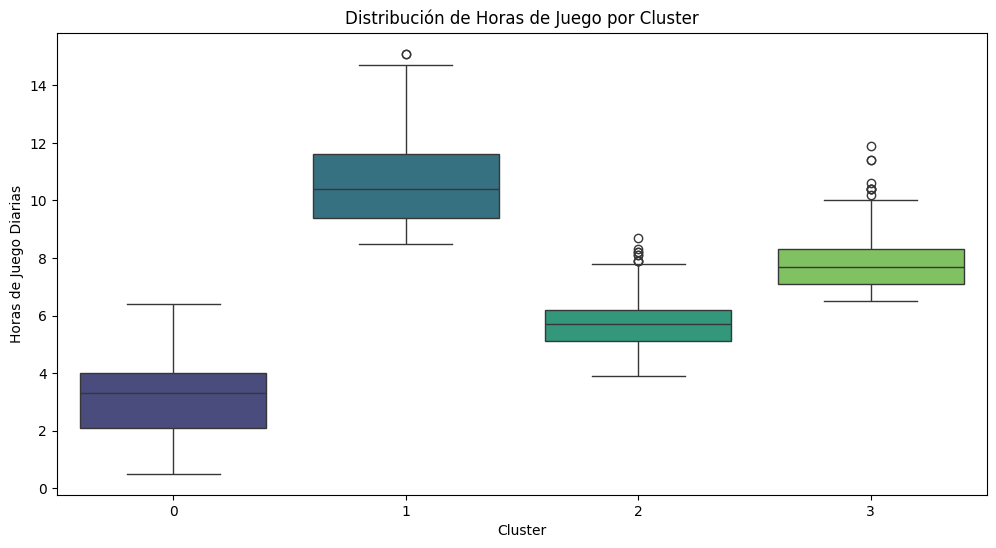

/tmp/ipykernel_32950/3651141248.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gm_ml, x='Cluster', y='gaming_addiction_risk_level_encoded', palette='viridis')


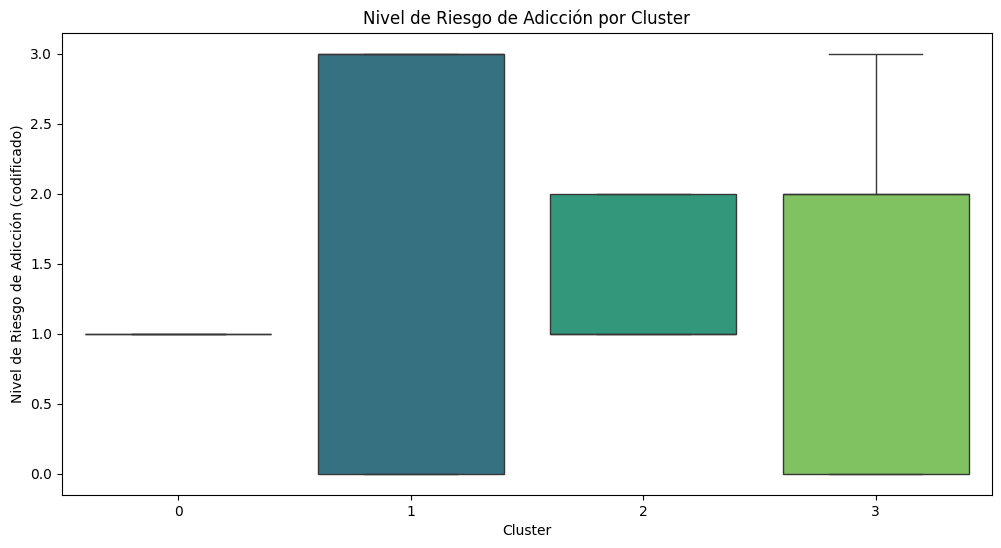

In [25]:
# Basado en el gráfico del método del codo, selecciona el número óptimo de clusters
# Por ejemplo, si el codo es visible en k=4, usa n_clusters=4
optimal_k = 4 # Puedes ajustar este valor manualmente tras observar el gráfico

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(df_clustering)

# Añadir las etiquetas de cluster al DataFrame original (gm_ml para análisis, no df_clustering escalado)
gm_ml['Cluster'] = clusters

# Visualizar la distribución de los clusters en función de algunas variables clave
plt.figure(figsize=(12, 6))
sns.scatterplot(data=gm_ml, x='daily_gaming_hours', y='sleep_hours', hue='Cluster', palette='viridis')
plt.title('Clusters de Jugadores por Horas de Juego y Horas de Sueño')
plt.xlabel('Horas de Juego Diarias (escalado)')
plt.ylabel('Horas de Sueño (escalado)')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=gm_ml, x='Cluster', y='daily_gaming_hours', palette='viridis')
plt.title('Distribución de Horas de Juego por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Horas de Juego Diarias')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=gm_ml, x='Cluster', y='gaming_addiction_risk_level_encoded', palette='viridis')
plt.title('Nivel de Riesgo de Adicción por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Nivel de Riesgo de Adicción (codificado)')
plt.show()


del cluster se sacan 4 grupos (como era de esperar) pero tampoco se consiguen informaciones relevantes para el estudio.

### Entrenamiento y Evaluación del Modelo Random Forest

Accuracy del modelo Random Forest: 0.9733

Informe de Clasificación del modelo Random Forest:
               precision    recall  f1-score   support

           0       0.95      0.89      0.92        46
           1       1.00      0.99      1.00       154
           2       0.97      0.98      0.97        57
           3       0.91      0.98      0.94        43

    accuracy                           0.97       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.97      0.97      0.97       300



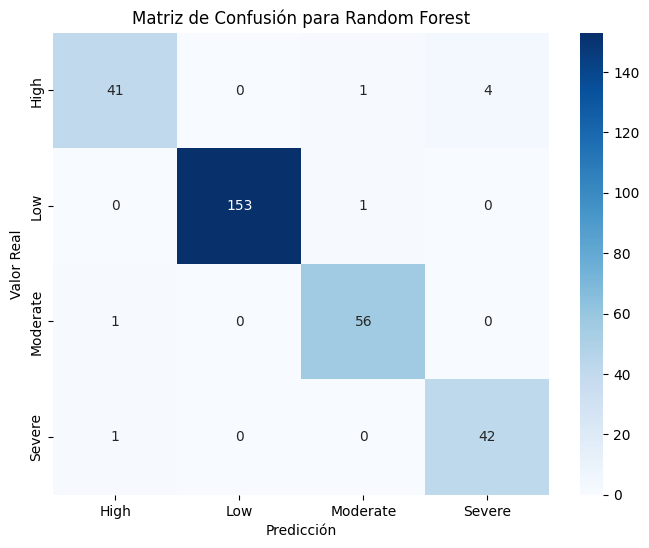

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Inicializar el modelo Random Forest
# Podemos ajustar el número de estimadores (árboles) y la profundidad máxima, entre otros hiperparámetros.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Entrenar el modelo con los datos de entrenamiento
rf_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Accuracy del modelo Random Forest: {accuracy_rf:.4f}")
print("\nInforme de Clasificación del modelo Random Forest:\n", report_rf)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(addiction_risk_mapping.keys()),
            yticklabels=list(addiction_risk_mapping.keys()))
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Random Forest')
plt.show()

el random forest resulta mucho mejor para evaluar lo que buscamos que en la regresión logística, a continuación veremos el árbol y como interpreta los resultados, para ver qué variables tienen más peso a la hora de hacer la predicción:

### Visualización de un árbol individual del Random Forest

Como el bosque tiene 100 árboles, visualizaremos solo uno para entender la lógica de las ramificaciones.

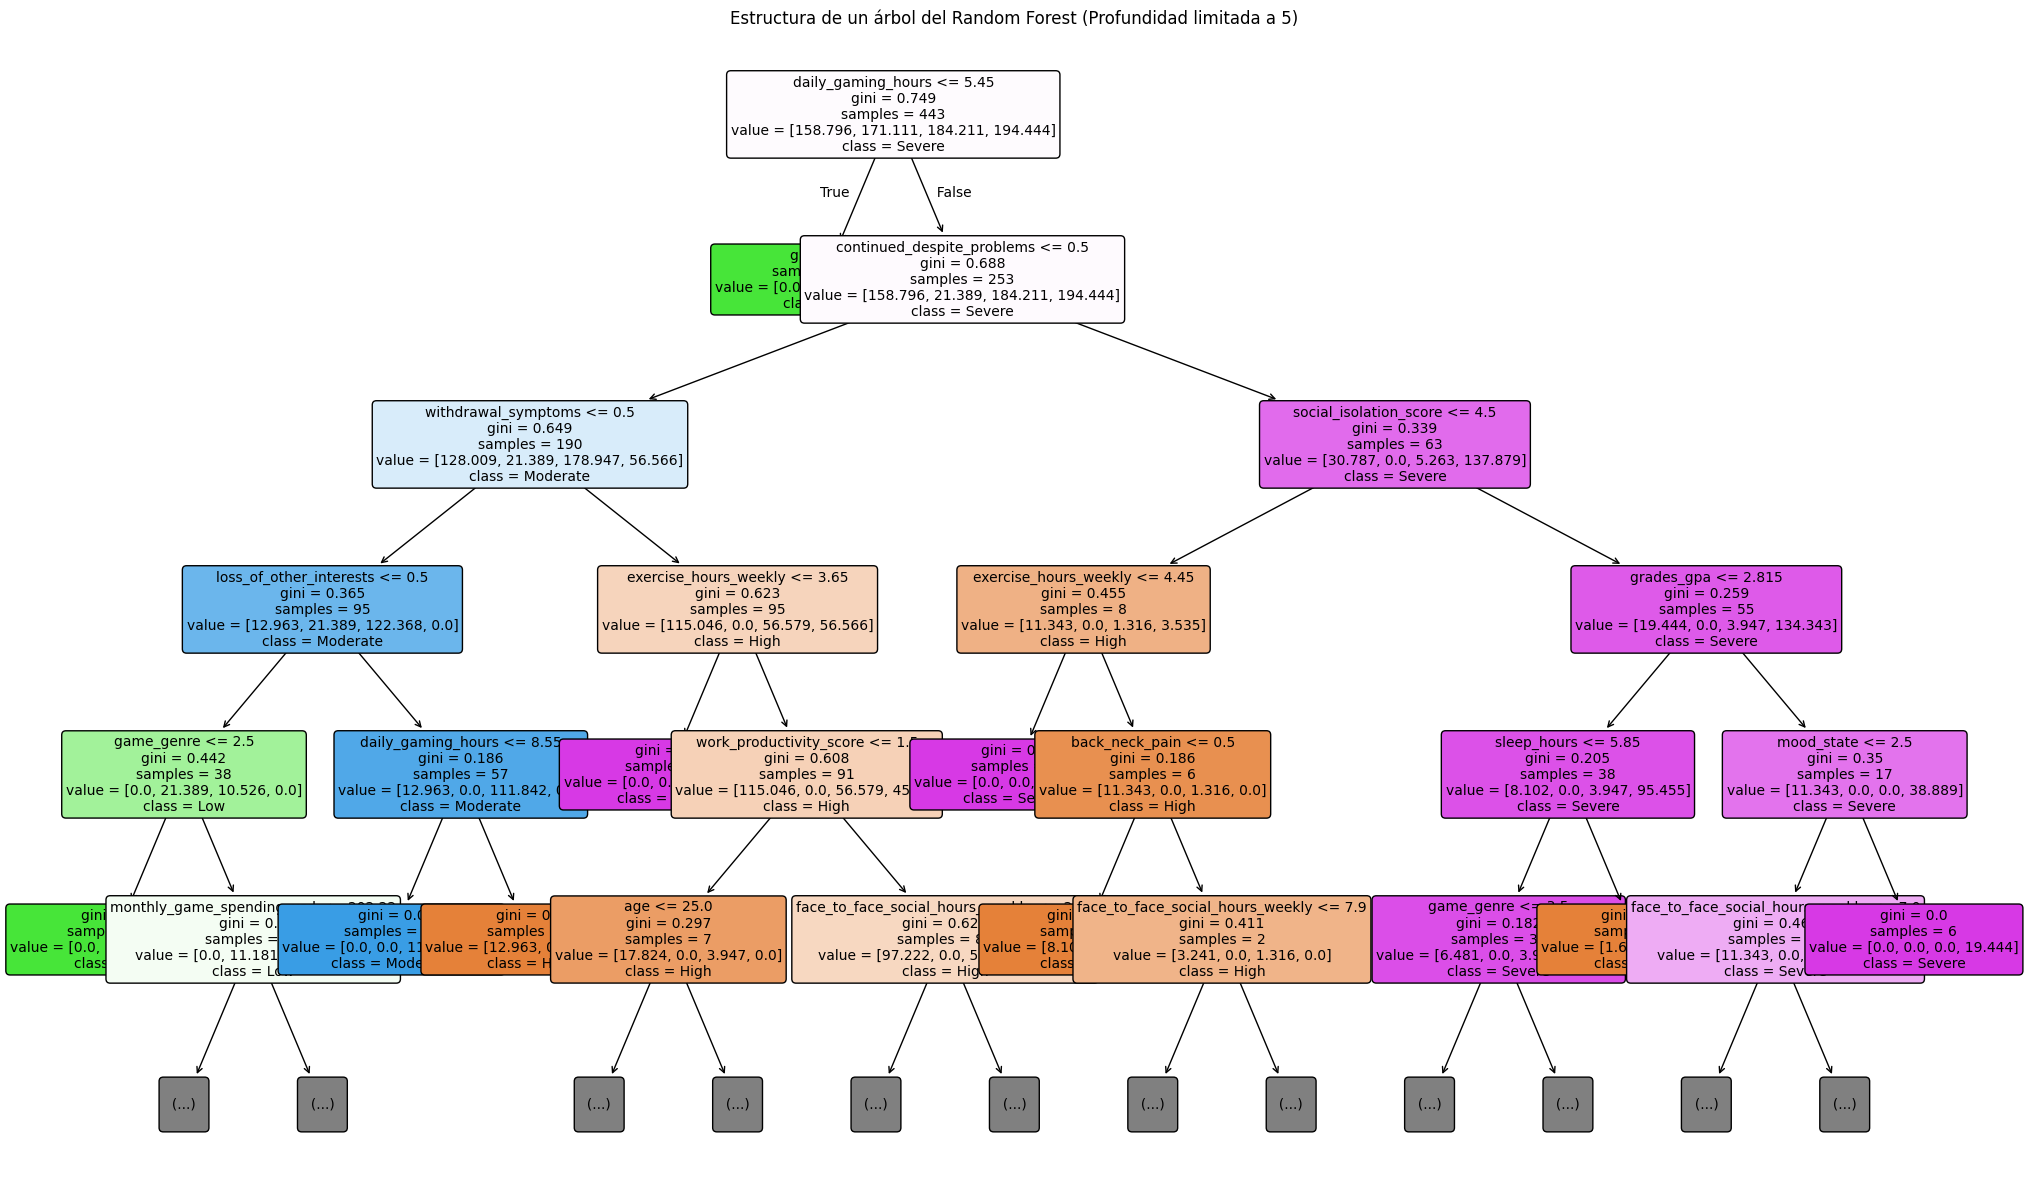

In [27]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Seleccionamos el primer árbol del bosque
estimador = rf_model.estimators_[0]

plt.figure(figsize=(25, 15))
plot_tree(estimador,
          feature_names=X.columns,
          class_names=list(addiction_risk_mapping.keys()),
          filled=True,
          rounded=True,
          max_depth=5,
          fontsize=10)

plt.title("Estructura de un árbol del Random Forest (Profundidad limitada a 5)")
plt.show()

### Análisis de Importancia de las Características (Random Forest)

Visualizaremos qué variables del dataset son las más determinantes para que el modelo clasifique el riesgo de adicción.

/tmp/ipykernel_32950/3709235641.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


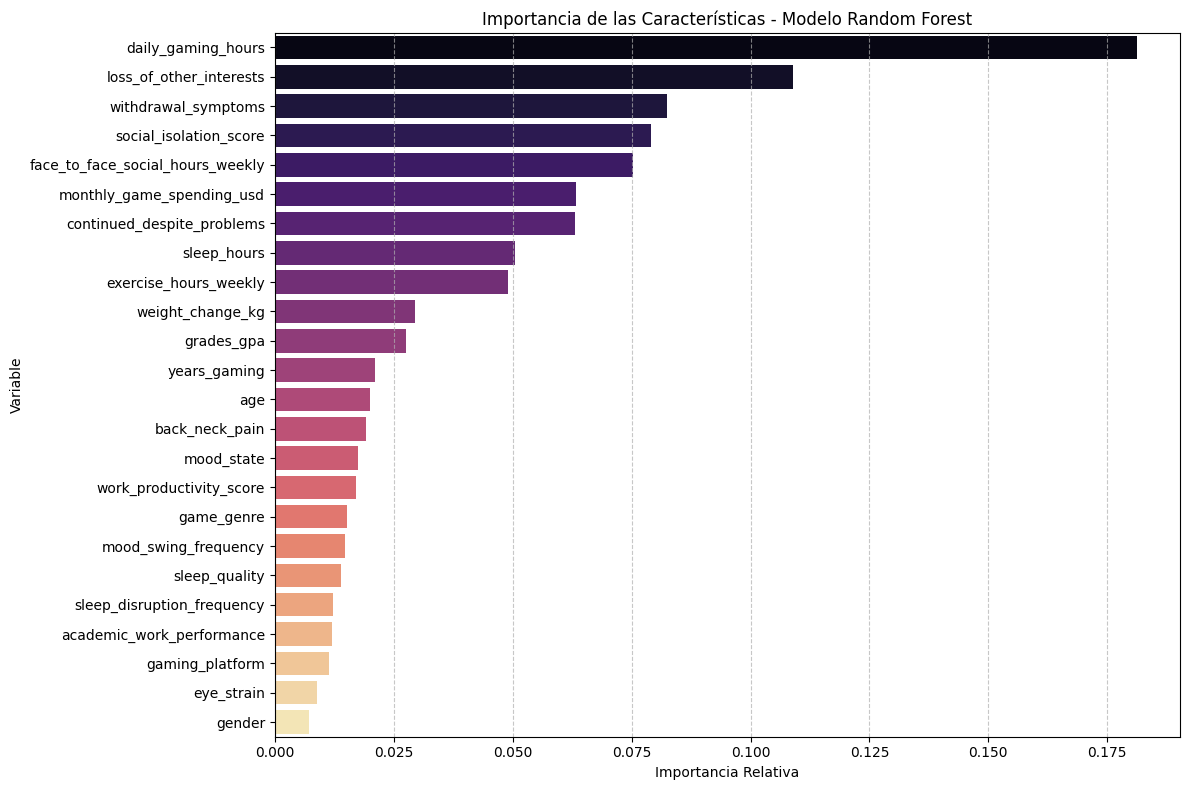

Top 5 variables más influyentes:
                             Feature  Importance
2                 daily_gaming_hours    0.181232
14           loss_of_other_interests    0.109015
13               withdrawal_symptoms    0.082428
20            social_isolation_score    0.079069
21  face_to_face_social_hours_weekly    0.075297


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Obtener las importancias del modelo entrenado
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Graficar
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Importancia de las Características - Modelo Random Forest')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Mostrar el top 5 por escrito
print("Top 5 variables más influyentes:")
print(feature_importance_df.head(5))

El modelo de random forest toma como variable más pesada la cantidad de horas jugadas, que era la variable más influyente que había en el EDA a la hora de clasificar los grupos de adicción.

Para ver no solo cuales son las características más influyentes, si no como afectan al modelo, uilizamos la librería SHAP:

<Figure size 1000x800 with 0 Axes>

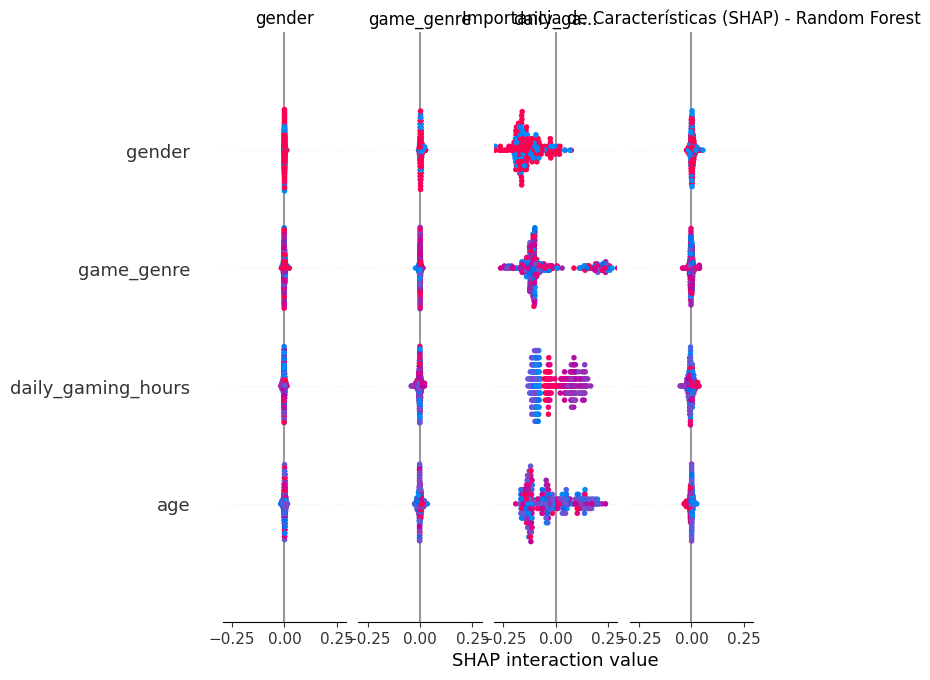

In [29]:
import shap

# Inicializar el explicador SHAP para el modelo Random Forest
explainer = shap.TreeExplainer(rf_model)

# Calcular valores SHAP (usamos una muestra del conjunto de prueba para mayor rapidez)
# Nota: SHAP para multiclase devuelve una lista de arrays, uno por cada clase
shap_values = explainer.shap_values(X_test)

# Visualizar la importancia global (Summary Plot)
# En multiclase, esto muestra la importancia media para todas las clases
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, class_names=list(addiction_risk_mapping.keys()), show=False)
plt.title('Importancia de Características (SHAP) - Random Forest')
plt.show()

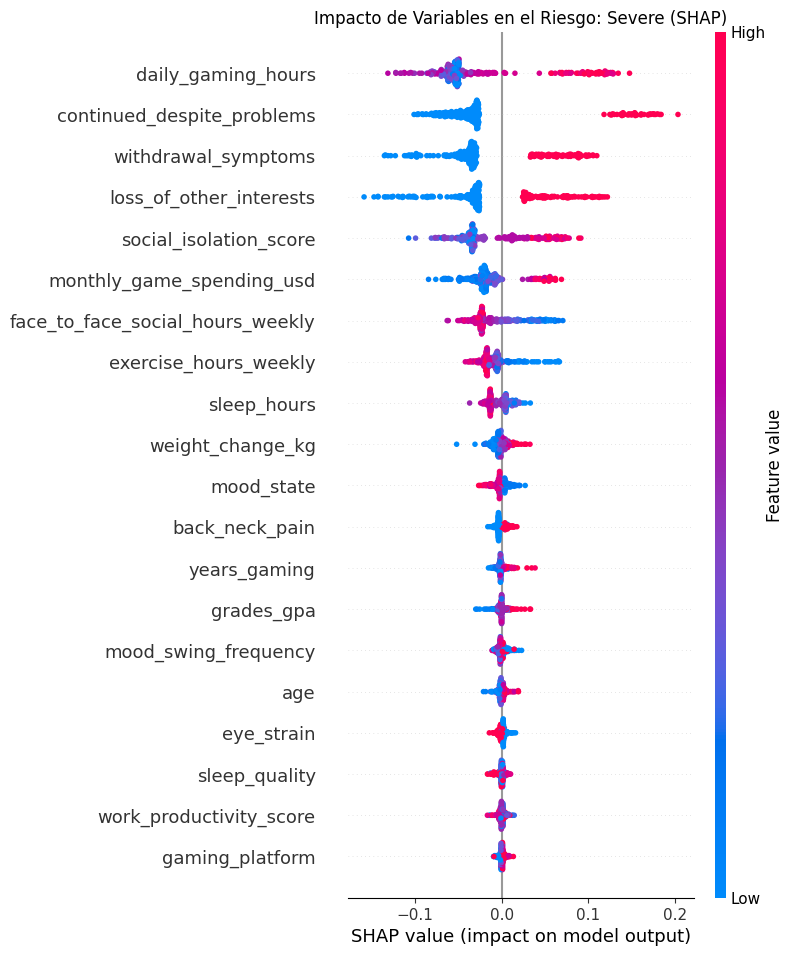

In [30]:
# Corregimos la selección del índice para la clase 'Severe'
# En versiones recientes de SHAP para multiclase, shap_values puede ser una lista o un array 3D
class_idx = int(addiction_risk_mapping['Severe'])

plt.figure(figsize=(10, 6))

# Lógica para manejar diferentes formatos de salida de SHAP
if isinstance(shap_values, list):
    # Si es una lista de arrays [muestras, variables]
    target_shap = shap_values[class_idx]
elif len(shap_values.shape) == 3:
    # Si es un array 3D [muestras, variables, clases]
    target_shap = shap_values[:, :, class_idx]
else:
    target_shap = shap_values

shap.summary_plot(target_shap, X_test, show=False)
plt.title(f'Impacto de Variables en el Riesgo: Severe (SHAP)')
plt.show()

### Entrenamiento y Evaluación de Gradient Boosting Classifier

Este modelo suele ofrecer un rendimiento superior al combinar mùltiples árboles de decisión de forma secuencial.

Accuracy del modelo Gradient Boosting: 0.9767

Informe de Clasificación:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        46
           1       1.00      0.99      1.00       154
           2       0.95      0.96      0.96        57
           3       0.98      0.98      0.98        43

    accuracy                           0.98       300
   macro avg       0.96      0.97      0.97       300
weighted avg       0.98      0.98      0.98       300



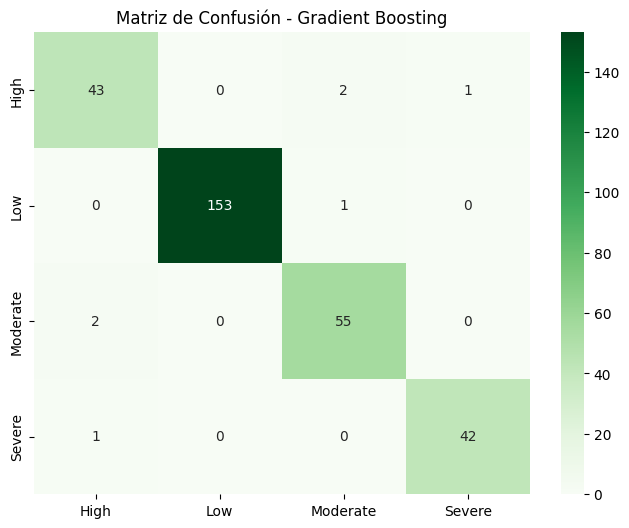

In [31]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Inicializar y entrenar el modelo
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

# Predicciones
y_pred_gb = gb_model.predict(X_test)

# Evaluación
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Accuracy del modelo Gradient Boosting: {accuracy_gb:.4f}")
print("\nInforme de Clasificación:\n", classification_report(y_test, y_pred_gb))

# Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d', cmap='Greens',
            xticklabels=list(addiction_risk_mapping.keys()),
            yticklabels=list(addiction_risk_mapping.keys()))
plt.title('Matriz de Confusión - Gradient Boosting')
plt.show()

### Importancia de las Características - Gradient Boosting

Analizamos cuáles son las variables que más influyen en las decisiones del modelo de Gradient Boosting.

/tmp/ipykernel_32950/1980146168.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=gb_feature_importance_df, palette='viridis')


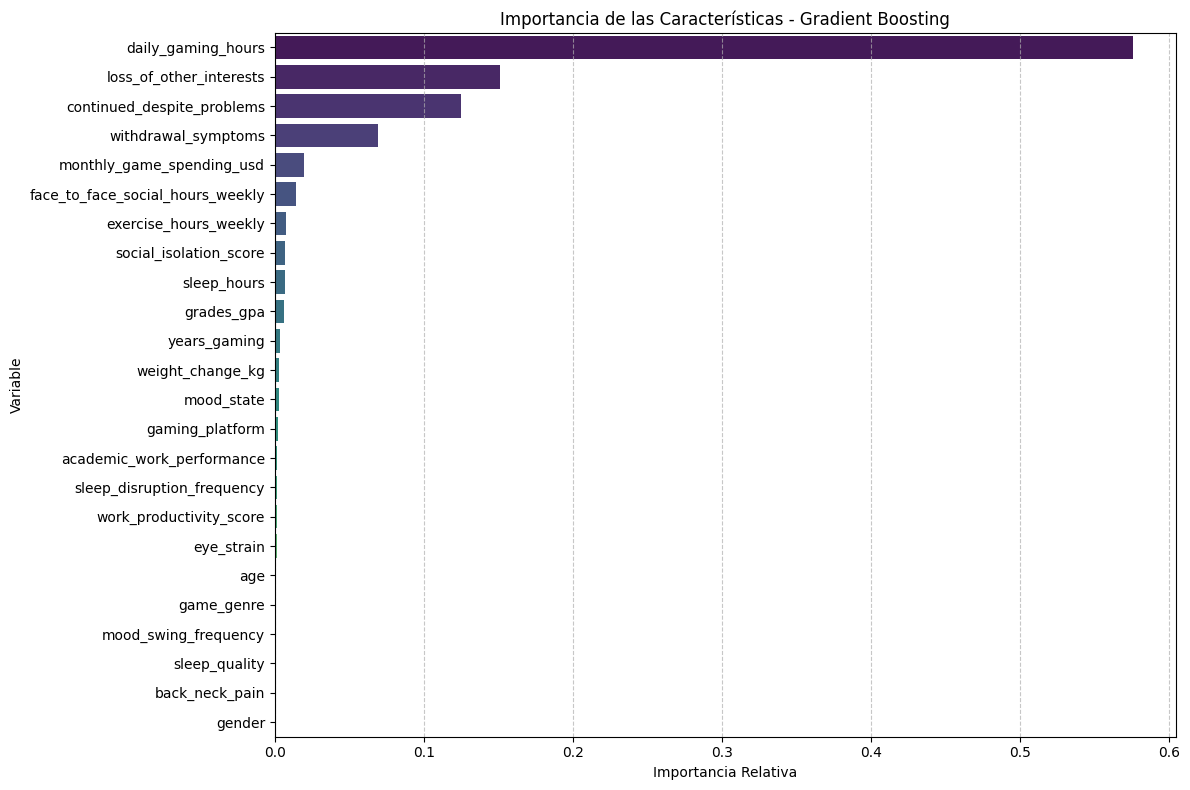

Top 5 variables más influyentes (Gradient Boosting):
                       Feature  Importance
2           daily_gaming_hours    0.575693
14     loss_of_other_interests    0.150923
15  continued_despite_problems    0.124764
13         withdrawal_symptoms    0.069075
22   monthly_game_spending_usd    0.019690


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer importancias del modelo Gradient Boosting
gb_importances = gb_model.feature_importances_
feature_names = X.columns
gb_feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': gb_importances})
gb_feature_importance_df = gb_feature_importance_df.sort_values(by='Importance', ascending=False)

# Graficar
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=gb_feature_importance_df, palette='viridis')
plt.title('Importancia de las Características - Gradient Boosting')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Mostrar el top 5
print("Top 5 variables más influyentes (Gradient Boosting):")
print(gb_feature_importance_df.head(5))

Como era de esperar, el gradient boosting también utiliza el nº de horas jugadas para determinar a qué grupo pertenece cada jugador, lo interesante aquí es que apenas tiene en cuenta otras variables, descartandolas casi de inmediato

In [33]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 19.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4be0414b3263adbcb5baeb2865474fbd4fc01eec7832023d6b224854667a4244
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [34]:
import lime
from lime import lime_tabular

# 1. Configurar el explicador de LIME
# Necesitamos pasarle los datos de entrenamiento para que aprenda la distribución de las variables
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=list(addiction_risk_mapping.keys()),
    mode='classification'
)

# 2. Elegir un caso del conjunto de prueba para explicar (por ejemplo, el primero)
i = 0
print(f"Explicando la predicción para el registro {i} del conjunto de prueba.")
print(f"Predicción del modelo: {list(addiction_risk_mapping.keys())[gb_model.predict(X_test.iloc[[i]])[0]]}")
print(f"Valor real: {list(addiction_risk_mapping.keys())[y_test.iloc[i]]}")

# 3. Generar la explicación
exp = explainer_lime.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=gb_model.predict_proba,
    num_features=10
)

# 4. Mostrar la explicación en el notebook
exp.show_in_notebook(show_table=True)

Explicando la predicción para el registro 0 del conjunto de prueba.
Predicción del modelo: Low
Valor real: Low


/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

### Entrenamiento y Evaluación de Multi-Layer Perceptron (MLP)

Las redes neuronales pueden capturar relaciones no lineales complejas. Utilizaremos `StandardScaler` para normalizar los datos, ya que las MLP son sensibles a la escala de las características.

Accuracy del modelo MLP: 0.9800

Informe de Clasificación:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        46
           1       1.00      1.00      1.00       154
           2       0.98      1.00      0.99        57
           3       0.95      0.93      0.94        43

    accuracy                           0.98       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.98      0.98      0.98       300



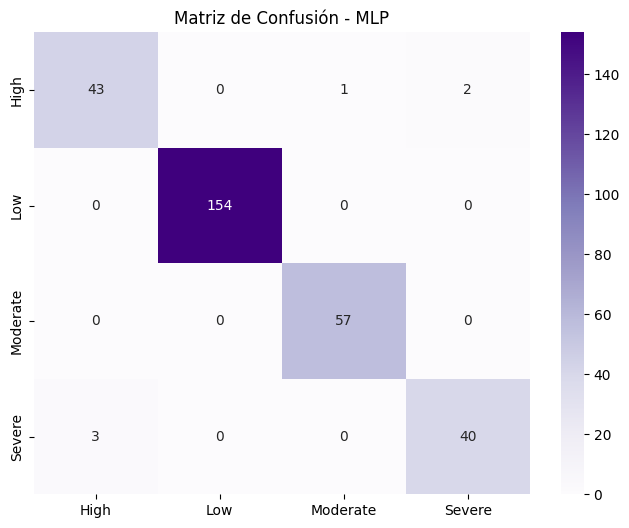

In [35]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Inicializar el MLP
# Usamos dos capas ocultas de 64 y 32 neuronas respectivamente
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

# 3. Entrenar el modelo
mlp_model.fit(X_train_scaled, y_train)

# 4. Predicciones
y_pred_mlp = mlp_model.predict(X_test_scaled)

# 5. Evaluación
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Accuracy del modelo MLP: {accuracy_mlp:.4f}")
print("\nInforme de Clasificación:\n", classification_report(y_test, y_pred_mlp))

# Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Purples',
            xticklabels=list(addiction_risk_mapping.keys()),
            yticklabels=list(addiction_risk_mapping.keys()))
plt.title('Matriz de Confusión - MLP')
plt.show()

como era de esperar del MLP, es el método de ML que más se acerca al resultado, aunque es el menos interpretable de todos.

/tmp/ipykernel_32950/3896426128.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=mlp_importances, palette='plasma')


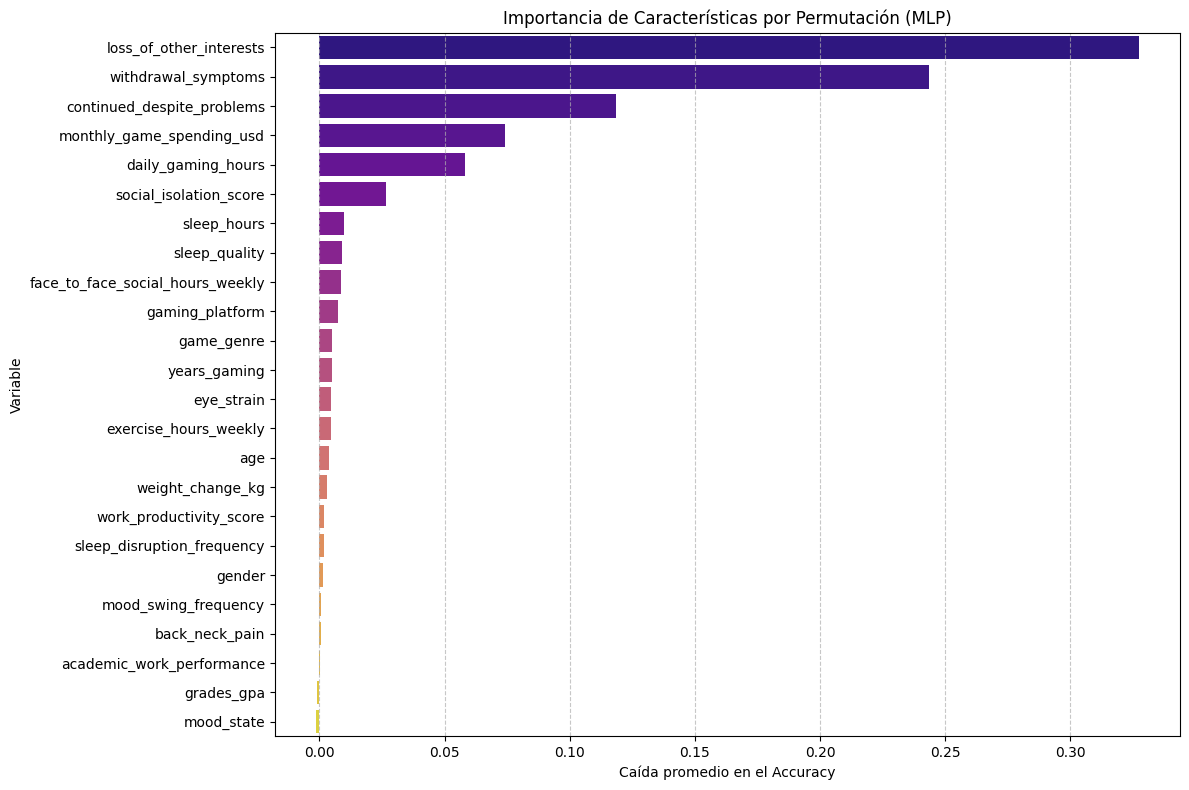

Top 5 variables críticas para la Red Neuronal:
                       Feature  Importance
14     loss_of_other_interests    0.327333
13         withdrawal_symptoms    0.243667
15  continued_despite_problems    0.118667
22   monthly_game_spending_usd    0.074000
2           daily_gaming_hours    0.058000


In [36]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la importancia por permutación en el conjunto de prueba
result = permutation_importance(mlp_model, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Crear DataFrame con los resultados
mlp_importances = pd.DataFrame({'Feature': X.columns, 'Importance': result.importances_mean})
mlp_importances = mlp_importances.sort_values(by='Importance', ascending=False)

# Graficar
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=mlp_importances, palette='plasma')
plt.title('Importancia de Características por Permutación (MLP)')
plt.xlabel('Caída promedio en el Accuracy')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 5 variables críticas para la Red Neuronal:")
print(mlp_importances.head(5))

Curiosamente, el MLP considera la variable más importante la perdida de otros intereses y no la cantidad de horas jugadas. De aquí se puede deducir que la cantidad de horas, si bien es un variable importante, quizás no sea la más importante a la hora de determinar el riesgo de adicción.

### Comparativa Final: Todos los Modelos de ML

Resumen de Accuracy para los modelos de Regresión Logística, Random Forest, Gradient Boosting y MLP.

,Modelo,Accuracy
3,MLP (Neural Network),0.980000
2,Gradient Boosting,0.976667
1,Random Forest,0.973333
0,Regresión Logística,0.863333


/tmp/ipykernel_32950/4017407721.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Modelo', data=df_final_results.sort_values(by='Accuracy', ascending=False), palette='viridis')


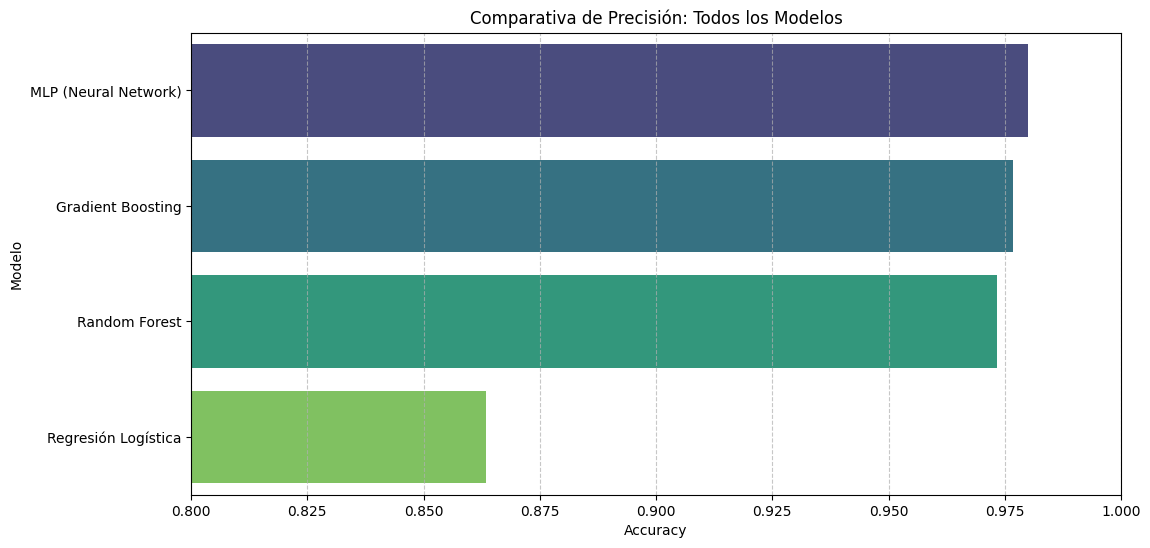

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Recopilar todos los resultados
final_results = {
    'Modelo': ['Regresión Logística', 'Random Forest', 'Gradient Boosting', 'MLP (Neural Network)'],
    'Accuracy': [accuracy_log_reg, accuracy_rf, accuracy_gb, accuracy_mlp]
}

# Crear DataFrame
df_final_results = pd.DataFrame(final_results)

# Mostrar tabla ordenada
display(df_final_results.sort_values(by='Accuracy', ascending=False))

# Graficar
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Modelo', data=df_final_results.sort_values(by='Accuracy', ascending=False), palette='viridis')
plt.title('Comparativa de Precisión: Todos los Modelos')
plt.xlim(0.8, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

##Conclusiones

La principal conclusión que se obtiene del análisis del dataset es que e estudio estaba sesgado. Los datos repartidos de forma uniforme en las variables "game_genre","game_platform","sleep_disruption_frecuency", "mood_swing_frecuency" demuestra esto.
Considerando esto, los datos no dejan de ser interesantes. La mayoría de la muestra poblacional está en el varemo de riego de adicción bajo. Dichas personas parecen tener tendencias sanas en relación con los videojuegos: juegan las horas justas, no sufen de daños fisicos o psíquicos ( dolor de ojos, disrupción del sueño, etc.) no gastan demasiado en videojuegos, mantienen relaciones interpersonales sanas, etc.
En principio parece que la mayoría de los encuestados no son propensos a la adicción.

Por otra parte, los miembros del grupo de adicción "severo" muestran los signos clásicos de adicción: juega una cantidad de horas insanas, de hasta 17 horas al día, no tienen casi relaciones interpersonales, sus gastos en videojuegos son exageradamente altos ( la mayoría de los encuestados no gastan más de 100€ al  mes) mantienen sus conductas adictivas aunque sufran por ello ("continued_despite_problems").


Sobre las conclusiones de los procesos de machine learning, se busco hacer que los modelos predictivos predijesen a qué grupo de riesgo de adicción pertenecían.
Se realizaron entrenamientos para estos modelos en el siguiente orden:

*   Regresión logística
*   Rando Forest
*   XGboost
*   MLP

Como era de esperar, cuanto mas sofisticado es el modelo, mejor predice la pertenencia al grupo de la muestra, pero menos interpetables son sus datos.
Para comporbar que variables toma por importantes cada modelo, se crea una tabla de importancia de características.

Todos los modelos, a excepción del MLP toman la variable "daily_gaming_hours" como el factor diferencial a la hora de clasificar el nivel de adicción. Lo interesante es que el MLP no la considera la más importante, poniendo las variables "loss_of_other_interest","withdrawal_symptoms","continued_despite_problems" y "monthly_game_spending_usd" por encima. Aún así, el modelo MLP tiene una tasa de predicción ligeramente más alta que el resto de modelos, lo que hace pensar que el tiempo de juego diario, aunque importante, no es el factor fundamental a la hora de determinar el nivel de adicción. Preciera que el cúmulo de conductas lesivas, con juego continuado a pesar de daños físicos o económicos son factores más importantes a la hora de determinar el nivel de adicción.

